# Improvement 2: Multi-start Confidence Reporting

Name 1: Muhammad Hamdan Sikandar

Rollnumber 1: 27100326

Name 2: Hadi Shazad Khan

Rollnumber 2: 27100475

Second improvement evaluated with the standardized report metrics.


## Runtime Scope

Defines execution assumptions, dataset path, and reproducibility settings.


In [1]:
import os
import json
import math
import random
import time
from collections import deque, namedtuple
from pathlib import Path
import builtins

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import nibabel as nib
from scipy.ndimage import label, find_objects

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from torch.utils.data import Dataset
from IPython.display import display

RUN_VERBOSE = False

def log_line(*args, **kwargs):
    if RUN_VERBOSE:
        builtins.print(*args, **kwargs)

try:
    import torchvision
    from torchvision import models
    from torchvision.transforms import functional as TF
except Exception as e:
    torchvision = None
    models = None
    log_line(f"WARNING: torchvision import failed: {e}")


RAW_DIR = "/kaggle/input/datasets/javariatahir123/lits17-liver-tumor-segmentation"
VOL_DIR = os.path.join(RAW_DIR, "CT_Vol", "CT_Vol")
SEG_DIR = os.path.join(RAW_DIR, "CT_Mask", "CT_Mask")
OUT_DIR = "/kaggle/working/improvement_2"
os.makedirs(OUT_DIR, exist_ok=True)


NUM_VOLUMES = 131
HU_MIN, HU_MAX = -200, 300
MIN_LESION_VOXELS = 10
MIN_BBOX_DIM = 4
SEED = 42

IMG_SIZE = 224
HISTORY_LEN = 10
NUM_ACTIONS = 9
ALPHA = 0.20
MAX_STEPS = 40

TRIGGER_EVAL_IOU = 0.50
TRIGGER_REWARD_IOU = TRIGGER_EVAL_IOU
TRIGGER_DEMO_IOU = 0.30
TRIGGER_IOU = TRIGGER_EVAL_IOU
TRIGGER_REWARD = 5.0
MIN_BOX_SIZE = 8
REWARD_MODE = "any"
USE_LARGEST_LESION_PER_VOLUME = False
TRIGGER_DEMO_PROB = 1.00

START_BOX_MODE_TRAIN = "full"
START_BOX_MODE_EVAL = "full"
USE_ACTION_MASK = True
BOX_FEATURE_DIM = 8
GUIDED_TRIGGER_ROLLOUT = True
GUIDED_TRIGGER_IOU = TRIGGER_EVAL_IOU
QUAL_MAX_BOX_AREA_FRAC = 0.20
QUAL_MAX_GT_AREA_FRAC = 0.04
QUAL_CENTER_WINDOW_FRAC = 0.30


TRIGGER_REWARD_CONTINUOUS = True
TRIGGER_CONT_SLOPE = 4.0
TRIGGER_CONT_INTERCEPT = -2.0
TIMEOUT_PENALTY = -5.0
SHAPE_REPEAT_PENALTY = 0.2
SHAPE_REPEAT_WINDOW = 3
SHAPE_ACTIONS = frozenset({4, 5, 6, 7})


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TOTAL_TIMESTEPS = 80_000
N_STEPS_PER_ROLLOUT = 2048

N_PPO_EPOCHS = 2
MINIBATCH_SIZE = 64
LR_PPO = 3e-5


ENCODER_UPDATE_DURING_PPO = False
LR_ENCODER = 0.0
ENCODER_MAX_GRAD_NORM = 0.5
ENCODER_FREEZE_BACKBONE = True
ENCODER_TRAIN_FC6_ONLY = True

GAMMA = 0.95
GAE_LAMBDA = 0.95
CLIP_COEF = 0.10
VF_COEF = 0.25
CLIP_VLOSS = True
VALUE_CLIP_COEF = 0.20
ENT_COEF = 0.001
ENT_COEF_ANNEAL = True
ENT_COEF_FINAL = 0.00015
MAX_GRAD_NORM = 0.5
NORMALIZE_ADVANTAGES = True
TARGET_KL = 0.012


BC_ENABLED = True
BC_EPISODES = 500
BC_EPOCHS = 5
BC_BATCH_SIZE = 256
BC_LR = 3e-4
BC_CHECKPOINT_PATH = os.path.join(OUT_DIR, "improvement_2_post_bc.pt")
BC_FORCE_RECOMPUTE = True


USE_TRIGGER_AUX_LOSS = True
TRIGGER_AUX_COEF = 0.50
TRIGGER_AUX_POS_IOU = TRIGGER_EVAL_IOU
TRIGGER_AUX_NEG_IOU = 0.25
TRIGGER_AUX_MARGIN = 1.00
TRIGGER_AUX_POS_WEIGHT = 2.00
TRIGGER_AUX_NEG_WEIGHT = 1.00
EVAL_TRIGGER_PROB = None


REPORT_BEST_ON_TIMEOUT = True
REPORT_BEST_ON_TRIGGER = False
REPORT_TIMEOUT_BOX_SELECTION = "stop_margin"
REPORT_PROTOCOL_NAME = "multistart_stop_confidence_report"
USE_MULTISTART_REPORTING = True
MULTISTART_EVAL_DURING_TRAINING = False
MULTISTART_NUM_STARTS = 7
MULTISTART_MIN_REPORT_STEP = 1
MULTISTART_MAX_REPORT_AREA_FRAC = 0.75


USE_CURRICULUM = True
CURRICULUM_PHASES = [
    {"name": "A_large", "min_diameter_mm": 20.0, "fraction": 0.30},
    {"name": "B_medium", "min_diameter_mm": 10.0, "fraction": 0.30},
    {"name": "C_all",    "min_diameter_mm": 0.0,  "fraction": 0.40},
]
USE_SOFT_TRANSITIONS = True
BLEND_STEPS = 4096
POOL_REFRESH_EVERY = 256


MAX_TRAIN_RECORDS = 300
MAX_VAL_RECORDS = 100
EVAL_EVERY_ROLLOUTS = 4
FAST_DEV_RUN = False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

log_line(f"device={DEVICE}")
log_line(f"output dir={OUT_DIR}")
log_line(f"Improvement 2: lr_policy={LR_PPO}, lr_encoder={LR_ENCODER}, encoder_update={ENCODER_UPDATE_DURING_PPO}, freeze_backbone={ENCODER_FREEZE_BACKBONE}, fc6_only={ENCODER_TRAIN_FC6_ONLY}")
log_line(f"target_kl={TARGET_KL}, n_ppo_epochs={N_PPO_EPOCHS}")
log_line(f"trigger reward strict={TRIGGER_REWARD_IOU:.2f}, base={TRIGGER_REWARD}, extra_slope={TRIGGER_CONT_SLOPE}, timeout_penalty={TIMEOUT_PENALTY}")
log_line(f"shape-repeat penalty={SHAPE_REPEAT_PENALTY} window={SHAPE_REPEAT_WINDOW}")
log_line(f"entropy anneal {ENT_COEF} -> {ENT_COEF_FINAL}")
log_line(f"curriculum soft={USE_SOFT_TRANSITIONS} blend_steps={BLEND_STEPS}")
log_line(f"report protocol={REPORT_PROTOCOL_NAME}, timeout_selection={REPORT_TIMEOUT_BOX_SELECTION}, best_on_timeout={REPORT_BEST_ON_TIMEOUT}")
log_line(f"multi-start reporting={USE_MULTISTART_REPORTING}, starts={MULTISTART_NUM_STARTS}, min_step={MULTISTART_MIN_REPORT_STEP}, max_area={MULTISTART_MAX_REPORT_AREA_FRAC}")

experiment_card_df = pd.DataFrame([
    {"field": "project_title", "value": "Improvement 2: Multi-start Confidence Reporting"},
    {"field": "name_1", "value": ""},
    {"field": "name_2", "value": ""},
    {"field": "roll_1", "value": ""},
    {"field": "roll_2", "value": ""},
    {"field": "experiment_name", "value": "Improvement 2"},
    {"field": "device", "value": DEVICE},
    {"field": "output_dir", "value": OUT_DIR},
    {"field": "seed", "value": SEED},
    {"field": "total_timesteps", "value": TOTAL_TIMESTEPS},
    {"field": "max_steps", "value": MAX_STEPS},
    {"field": "reward_mode", "value": REWARD_MODE},
    {"field": "encoder_update_during_ppo", "value": ENCODER_UPDATE_DURING_PPO},
    {"field": "bc_enabled", "value": BC_ENABLED},
    {"field": "action_masking", "value": USE_ACTION_MASK},
])
display(experiment_card_df)


,field,value
0,project_title,Improvement 2: Multi-start Confidence Reporting
1,name_1,
2,name_2,
3,roll_1,
4,roll_2,
5,experiment_name,Improvement 2
6,device,cuda
7,output_dir,/kaggle/working/improvement_2
8,seed,42
9,total_timesteps,80000


## Imports and Configuration

Loads dependencies, constants, output paths, and report metadata.


In [2]:

def find_nii(data_dir, prefix, idx):
    for ext in (".nii", ".nii.gz"):
        for name in (f"{prefix}-{idx}{ext}", f"{prefix}_{idx}{ext}", f"{prefix}-{idx:03d}{ext}"):
            p = os.path.join(data_dir, name)
            if os.path.exists(p):
                return p
    return None


def window_norm(vol, lo=HU_MIN, hi=HU_MAX):
    return ((np.clip(vol, lo, hi) - lo) / (hi - lo)).astype(np.float32)


def extract_bboxes_3d(seg, shape):
    tumor = (seg == 2).astype(np.uint8)
    labeled, n = label(tumor)
    if n == 0:
        return []
    lesions = []
    for i, slc in enumerate(find_objects(labeled)):
        if slc is None:
            continue
        voxels = int(np.sum(labeled[slc] == i + 1))
        if voxels < MIN_LESION_VOXELS:
            continue
        bbox = np.array([[s.start, s.stop] for s in slc], dtype=np.int64)
        for ax in range(3):
            d = bbox[ax, 1] - bbox[ax, 0]
            if d < MIN_BBOX_DIM:
                pad = MIN_BBOX_DIM - d
                bbox[ax, 0] = max(0, bbox[ax, 0] - pad // 2)
                bbox[ax, 1] = min(shape[ax], bbox[ax, 0] + MIN_BBOX_DIM)
        lesions.append({
            "bbox": bbox.tolist(),
            "voxels": voxels,
            "dims_vox": (bbox[:, 1] - bbox[:, 0]).tolist(),
        })
    return lesions


def build_or_load_metadata():
    meta_path = os.path.join(OUT_DIR, "metadata.json")
    split_path = os.path.join(OUT_DIR, "splits.json")
    if os.path.exists(meta_path) and os.path.exists(split_path):
        with open(meta_path) as f:
            metadata = json.load(f)
        with open(split_path) as f:
            splits = json.load(f)
        log_line(f"Loaded metadata: {len(metadata)} volumes")
        return metadata, splits

    metadata = {}
    for vid in range(NUM_VOLUMES):
        vp = find_nii(VOL_DIR, "volume", vid)
        sp = find_nii(SEG_DIR, "segmentation", vid)
        if vp is None or sp is None:
            log_line(f"skip vol {vid}: missing volume or segmentation")
            continue
        vol_nii = nib.load(vp)
        seg = nib.load(sp).get_fdata()
        spacing = [float(x) for x in vol_nii.header.get_zooms()[:3]]
        lesions = extract_bboxes_3d(seg, seg.shape)
        for les in lesions:
            les["dims_mm"] = [float(d * s) for d, s in zip(les["dims_vox"], spacing)]
            les["diameter_mm"] = max(les["dims_mm"])
        metadata[str(vid)] = {
            "shape": list(seg.shape),
            "spacing": spacing,
            "num_lesions": len(lesions),
            "lesions": lesions,
        }
        if vid % 10 == 0:
            log_line(f"vol {vid}: shape={seg.shape}, lesions={len(lesions)}")

    vol_ids = sorted(int(k) for k, v in metadata.items() if v["num_lesions"] > 0)
    rng = np.random.RandomState(SEED)
    rng.shuffle(vol_ids)
    n = len(vol_ids)
    n_train = int(0.76 * n)
    n_val = int(0.12 * n)
    splits = {
        "train": sorted(vol_ids[:n_train]),
        "val": sorted(vol_ids[n_train:n_train + n_val]),
        "test": sorted(vol_ids[n_train + n_val:]),
    }

    with open(meta_path, "w") as f:
        json.dump(metadata, f)
    with open(split_path, "w") as f:
        json.dump(splits, f)

    log_line(f"Built metadata: {len(metadata)} volumes, {sum(v['num_lesions'] for v in metadata.values())} lesions")
    return metadata, splits


METADATA, SPLITS = build_or_load_metadata()
for split, ids in SPLITS.items():
    n_les = sum(METADATA[str(v)]["num_lesions"] for v in ids)
    log_line(f"{split:5s}: {len(ids):3d} volumes, {n_les:4d} 3D lesions")

split_summary_df = pd.DataFrame([
    {"split": split, "volumes": len(ids), "lesions_3d": sum(METADATA[str(v)]["num_lesions"] for v in ids)}
    for split, ids in SPLITS.items()
])
display(split_summary_df)


,split,volumes,lesions_3d
0,train,89,624
1,val,14,132
2,test,15,128


## Metadata Loader

Builds or loads lesion metadata and split definitions.


In [3]:

def bbox3d_to_axial_box2d(bbox3d):
    b = np.asarray(bbox3d, dtype=np.int64)

    y1, y2 = int(b[0, 0]), int(b[0, 1])
    x1, x2 = int(b[1, 0]), int(b[1, 1])
    return np.array([x1, y1, x2, y2], dtype=np.int64)


def lesion_center_slice(bbox3d):
    b = np.asarray(bbox3d, dtype=np.int64)
    return int((b[2, 0] + b[2, 1] - 1) // 2)


def build_2d_records(split):
    records = []
    for vid in SPLITS[split]:
        info = METADATA[str(vid)]
        for target_idx, target_les in enumerate(info["lesions"]):
            z = lesion_center_slice(target_les["bbox"])
            boxes = []
            for les in info["lesions"]:
                b = np.asarray(les["bbox"], dtype=np.int64)
                if b[2, 0] <= z < b[2, 1]:
                    box2d = bbox3d_to_axial_box2d(b)
                    if (box2d[2] - box2d[0]) >= 2 and (box2d[3] - box2d[1]) >= 2:
                        boxes.append(box2d.tolist())
            if not boxes:
                continue
            records.append({
                "vid": int(vid),
                "slice": int(z),
                "target_idx": int(target_idx),
                "target_box": bbox3d_to_axial_box2d(target_les["bbox"]).tolist(),
                "boxes": boxes,
                "diameter_mm": float(target_les["diameter_mm"]),
                "shape2d": [int(info["shape"][0]), int(info["shape"][1])],
            })
    return records


RECORDS = {split: build_2d_records(split) for split in ["train", "val", "test"]}
for split, recs in RECORDS.items():
    log_line(f"{split:5s}: {len(recs):4d} 2D records")

assert len(RECORDS["train"]) > 0, "No training records built"

record_summary_df = pd.DataFrame([
    {"split": split, "records_2d": len(recs)}
    for split, recs in RECORDS.items()
])
display(record_summary_df)


,split,records_2d
0,train,624
1,val,132
2,test,128


## 2D Lesion Records

Converts lesion metadata into axial 2D localization records.


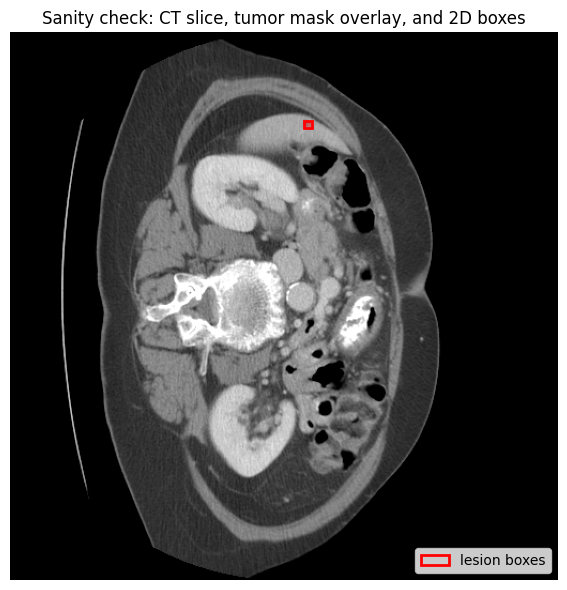

In [4]:

class VolumeCache:
    def __init__(self, max_size=2):
        self.max_size = max_size
        self.cache = {}
        self.order = []

    def get_volume(self, vid):
        key = ("vol", int(vid))
        if key in self.cache:
            return self.cache[key]
        p = find_nii(VOL_DIR, "volume", int(vid))
        if p is None:
            raise FileNotFoundError(f"volume {vid} not found")
        vol = nib.load(p).get_fdata().astype(np.float32)
        vol = window_norm(vol)
        self._put(key, vol)
        return vol

    def get_seg(self, vid):
        key = ("seg", int(vid))
        if key in self.cache:
            return self.cache[key]
        p = find_nii(SEG_DIR, "segmentation", int(vid))
        if p is None:
            raise FileNotFoundError(f"segmentation {vid} not found")
        seg = nib.load(p).get_fdata().astype(np.int16)
        self._put(key, seg)
        return seg

    def _put(self, key, value):
        if len(self.order) >= self.max_size:
            old = self.order.pop(0)
            self.cache.pop(old, None)
        self.cache[key] = value
        self.order.append(key)


CACHE = VolumeCache(max_size=16)


def draw_boxes(ax, boxes, color="red", linewidth=2, label=None):
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(float, box)
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=linewidth, edgecolor=color, facecolor="none",
            label=label if i == 0 else None,
        ))


def show_record(record, title=None):
    vol = CACHE.get_volume(record["vid"])
    seg = CACHE.get_seg(record["vid"])
    z = record["slice"]
    img = vol[:, :, z]
    mask = (seg[:, :, z] == 2)

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.35)
    draw_boxes(ax, record["boxes"], color="red", linewidth=2, label="lesion boxes")
    ax.set_title(title or f"vol={record['vid']} slice={z} boxes={len(record['boxes'])}")
    ax.axis("off")
    if len(record["boxes"]) > 0:
        ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


sample = RECORDS["train"][0]
show_record(sample, "Sanity check: CT slice, tumor mask overlay, and 2D boxes")

## Volume Cache and Visual Check

Caches volumes and renders a quick record-level sanity check.


In [5]:
ACTION_NAMES = {
    0: "right", 1: "left", 2: "down", 3: "up",
    4: "bigger", 5: "smaller", 6: "fatter", 7: "taller", 8: "trigger",
}
OPPOSITE = {0: 1, 1: 0, 2: 3, 3: 2, 4: 5, 5: 4, 6: 7, 7: 6}


def box_iou_2d(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    if inter <= 0:
        return 0.0
    area_a = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    area_b = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    return float(inter / (area_a + area_b - inter + 1e-8))


def max_iou_2d(box, boxes):
    return max((box_iou_2d(box, b) for b in boxes), default=0.0)


def clip_box_2d(box, h, w, min_size=MIN_BOX_SIZE):
    x1, y1, x2, y2 = [int(round(v)) for v in box]
    x1 = max(0, min(x1, w - 1)); x2 = max(1, min(x2, w))
    y1 = max(0, min(y1, h - 1)); y2 = max(1, min(y2, h))

    if x2 - x1 < min_size:
        cx = (x1 + x2) // 2
        x1 = max(0, cx - min_size // 2)
        x2 = min(w, x1 + min_size)
        x1 = max(0, x2 - min_size)
    if y2 - y1 < min_size:
        cy = (y1 + y2) // 2
        y1 = max(0, cy - min_size // 2)
        y2 = min(h, y1 + min_size)
        y1 = max(0, y2 - min_size)

    return np.array([x1, y1, x2, y2], dtype=np.int64)


def apply_action_2d(box, action, image_shape, alpha=ALPHA):
    h, w = int(image_shape[0]), int(image_shape[1])
    box = np.asarray(box, dtype=np.float32).copy()
    x1, y1, x2, y2 = box
    bw = max(1.0, x2 - x1)
    bh = max(1.0, y2 - y1)
    dx = max(1.0, round(alpha * bw))
    dy = max(1.0, round(alpha * bh))

    if action == 0:
        x1 += dx; x2 += dx
    elif action == 1:
        x1 -= dx; x2 -= dx
    elif action == 2:
        y1 += dy; y2 += dy
    elif action == 3:
        y1 -= dy; y2 -= dy
    elif action == 4:
        x1 -= dx / 2; x2 += dx / 2; y1 -= dy / 2; y2 += dy / 2
    elif action == 5:
        x1 += dx / 2; x2 -= dx / 2; y1 += dy / 2; y2 -= dy / 2
    elif action == 6:
        x1 -= dx / 2; x2 += dx / 2; y1 += dy / 2; y2 -= dy / 2
    elif action == 7:
        x1 += dx / 2; x2 -= dx / 2; y1 -= dy / 2; y2 += dy / 2
    elif action == 8:
        pass
    else:
        raise ValueError(f"unknown action {action}")

    return clip_box_2d([x1, y1, x2, y2], h, w)


def get_starting_box_candidates(h, w):
    """Return a list of [x1,y1,x2,y2] starting boxes covering the image at multiple scales."""
    boxes = []

    boxes.append([0, 0, w, h])

    px, py = int(0.10 * w), int(0.10 * h)
    boxes.append([px, py, w - px, h - py])

    mx, my = w // 2, h // 2
    boxes.append([0, 0, mx, my])
    boxes.append([mx, 0, w, my])
    boxes.append([0, my, mx, h])
    boxes.append([mx, my, w, h])

    sw, sh = int(0.40 * w), int(0.40 * h)
    boxes.append([0, 0, sw, sh])
    boxes.append([w - sw, 0, w, sh])
    boxes.append([0, h - sh, sw, h])
    boxes.append([w - sw, h - sh, w, h])
    cx, cy = w // 2, h // 2
    boxes.append([cx - sw // 2, cy - sh // 2, cx + sw // 2, cy + sh // 2])
    return [np.array(b, dtype=np.int64) for b in boxes]


assert abs(box_iou_2d([0, 0, 10, 10], [0, 0, 10, 10]) - 1.0) < 1e-6
assert box_iou_2d([0, 0, 10, 10], [20, 20, 30, 30]) == 0.0
assert 0.0 < box_iou_2d([0, 0, 10, 10], [5, 5, 15, 15]) < 1.0
log_line("IoU and action utilities ready")
log_line(f"start-box candidate templates: {len(get_starting_box_candidates(512, 512))} per slice")

action_space_df = pd.DataFrame([
    {"action_id": k, "action_name": v}
    for k, v in ACTION_NAMES.items()
])
display(action_space_df)


,action_id,action_name
0,0,right
1,1,left
2,2,down
3,3,up
4,4,bigger
5,5,smaller
6,6,fatter
7,7,taller
8,8,trigger


In [6]:
def trigger_reward_value(iou):
    """Strict stop reward aligned with IoU@0.5 evaluation.

    Below-threshold trigger is a fixed terminal error. The old linear ramp made
    an IoU=0.49 trigger much less bad than timing out, which teaches PPO to stop
    near the threshold even when the reported metric counts it as failure.
    """
    iou = float(iou)
    if iou >= TRIGGER_REWARD_IOU:
        if TRIGGER_REWARD_CONTINUOUS:
            return TRIGGER_REWARD + TRIGGER_CONT_SLOPE * (iou - TRIGGER_REWARD_IOU)
        return TRIGGER_REWARD
    return -TRIGGER_REWARD


class Caicedo2DEnv:
    """Active-localization environment for a single axial slice.

    v4 reward shaping (toggleable via config flags):
      * Threshold-centered trigger reward: negative below TRIGGER_REWARD_IOU and clearly
        positive at/above the strict eval threshold.
      * Shape-repeat penalty: subtract SHAPE_REPEAT_PENALTY if the last SHAPE_REPEAT_WINDOW
        actions are all shape-changing (bigger/smaller/fatter/taller). This penalty applies
        AFTER the IoU-based movement reward and does NOT apply on a trigger step.
    """

    def __init__(self, records, reward_mode=REWARD_MODE, max_steps=MAX_STEPS,
                 alpha=ALPHA, start_box_mode=START_BOX_MODE_TRAIN):
        assert reward_mode in {"any", "target"}
        assert start_box_mode in {"full", "random_multi"}
        self.records = list(records)
        self.reward_mode = reward_mode
        self.max_steps = int(max_steps)
        self.alpha = float(alpha)
        self.start_box_mode = start_box_mode
        self.rng = np.random.RandomState(SEED)
        self.reset()

    def reset(self, record=None, seed=None, start_box_mode=None):
        if seed is not None:
            self.rng = np.random.RandomState(seed)
        if record is None:
            record = self.records[int(self.rng.randint(len(self.records)))]
        self.record = record
        self.vol = CACHE.get_volume(record["vid"])
        self.image = self.vol[:, :, record["slice"]].astype(np.float32)
        self.h, self.w = self.image.shape
        self.boxes = [np.asarray(b, dtype=np.int64) for b in record["boxes"]]
        self.target_box = np.asarray(record["target_box"], dtype=np.int64)
        self.reward_boxes = [self.target_box] if self.reward_mode == "target" else self.boxes

        mode = start_box_mode if start_box_mode is not None else self.start_box_mode
        if mode == "random_multi":
            cands = get_starting_box_candidates(self.h, self.w)
            idx = int(self.rng.randint(len(cands)))
            box = cands[idx].astype(np.int64).copy()
            jx = int(self.rng.randint(-int(0.05 * self.w), int(0.05 * self.w) + 1))
            jy = int(self.rng.randint(-int(0.05 * self.h), int(0.05 * self.h) + 1))
            box[0] += jx; box[2] += jx
            box[1] += jy; box[3] += jy
            self.box = clip_box_2d(box, self.h, self.w)
        else:
            self.box = np.array([0, 0, self.w, self.h], dtype=np.int64)

        self.history = np.zeros((HISTORY_LEN, NUM_ACTIONS), dtype=np.float32)
        self.step_count = 0
        self.prev_iou = max_iou_2d(self.box, self.reward_boxes)
        self.best_iou = self.prev_iou
        self.last_action = None

        self.recent_actions = deque(maxlen=SHAPE_REPEAT_WINDOW)
        return self._obs(), self._info(triggered=False, timed_out=False)

    def crop(self, box=None):
        if box is None:
            box = self.box
        x1, y1, x2, y2 = map(int, box)
        patch = self.image[y1:y2, x1:x2]
        if patch.size == 0:
            patch = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
        t = torch.from_numpy(patch[None, None].astype(np.float32))
        out = F.interpolate(t, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        return out.squeeze(0).numpy().astype(np.float32)

    def _obs(self):
        return {
            "crop": self.crop(),
            "history": self.history.flatten().copy(),
            "box": self.box.copy(),
            "image_shape": np.array([self.h, self.w], dtype=np.float32),
        }

    def _info(self, triggered, timed_out):
        return {
            "iou": float(self.prev_iou),
            "best_iou": float(self.best_iou),
            "triggered": bool(triggered),
            "timed_out": bool(timed_out),
            "steps": int(self.step_count),
            "vid": int(self.record["vid"]),
            "slice": int(self.record["slice"]),
            "diameter_mm": float(self.record["diameter_mm"]),
        }

    def movement_reward_for_action(self, action):
        next_box = apply_action_2d(self.box, action, self.image.shape, alpha=self.alpha)
        next_iou = max_iou_2d(next_box, self.reward_boxes)
        if next_iou > self.prev_iou:
            return 1.0
        if next_iou < self.prev_iou:
            return -1.0
        return 0.0

    def available_actions(self, previous_action=None):
        actions = list(range(NUM_ACTIONS))
        if USE_ACTION_MASK and previous_action is not None and previous_action < 8:
            opposite = OPPOSITE.get(int(previous_action))
            if opposite in actions and len(actions) > 1:
                actions.remove(opposite)

        filtered = []
        for action in actions:
            if action == 8:
                filtered.append(action)
                continue
            next_box = apply_action_2d(self.box, action, self.image.shape, alpha=self.alpha)
            if not np.array_equal(next_box, self.box):
                filtered.append(action)
        return filtered if filtered else actions

    def positive_actions(self):
        allowed = set(self.available_actions(self.last_action))
        positives = [a for a in range(8) if a in allowed and self.movement_reward_for_action(a) > 0]
        if self.prev_iou >= TRIGGER_REWARD_IOU and 8 in allowed:
            positives.append(8)
        return positives if positives else self.available_actions(self.last_action)

    def _trigger_reward(self):
        """v4 continuous trigger reward, with discrete fallback if flag is off."""
        return trigger_reward_value(self.prev_iou)

    def step(self, action):
        action = int(action)
        self.step_count += 1

        if action == 8:
            reward = self._trigger_reward()
            done = True
            return self._obs(), float(reward), done, self._info(triggered=True, timed_out=False)

        next_box = apply_action_2d(self.box, action, self.image.shape, alpha=self.alpha)
        next_iou = max_iou_2d(next_box, self.reward_boxes)
        if next_iou > self.prev_iou:
            reward = 1.0
        elif next_iou < self.prev_iou:
            reward = -1.0
        else:
            reward = 0.0


        self.recent_actions.append(action)
        if (
            SHAPE_REPEAT_PENALTY > 0.0
            and len(self.recent_actions) == SHAPE_REPEAT_WINDOW
            and all(a in SHAPE_ACTIONS for a in self.recent_actions)
        ):
            reward -= SHAPE_REPEAT_PENALTY

        self.box = next_box
        self.prev_iou = float(next_iou)
        self.best_iou = max(self.best_iou, self.prev_iou)
        self.history = np.roll(self.history, -1, axis=0)
        self.history[-1] = 0.0
        self.history[-1, action] = 1.0
        self.last_action = action

        timed_out = self.step_count >= self.max_steps
        if timed_out:
            reward += TIMEOUT_PENALTY
        done = bool(timed_out)
        return self._obs(), float(reward), done, self._info(triggered=False, timed_out=timed_out)


def keep_largest_lesion_per_volume(records):
    best = {}
    for rec in records:
        vid = int(rec["vid"])
        if vid not in best or float(rec["diameter_mm"]) > float(best[vid]["diameter_mm"]):
            best[vid] = rec
    return list(best.values())


base_train_records = keep_largest_lesion_per_volume(RECORDS["train"]) if USE_LARGEST_LESION_PER_VOLUME else RECORDS["train"]
base_val_records = keep_largest_lesion_per_volume(RECORDS["val"]) if USE_LARGEST_LESION_PER_VOLUME else RECORDS["val"]
base_test_records = keep_largest_lesion_per_volume(RECORDS["test"]) if USE_LARGEST_LESION_PER_VOLUME else RECORDS["test"]

train_records = base_train_records[:MAX_TRAIN_RECORDS] if MAX_TRAIN_RECORDS else base_train_records
val_records = base_val_records[:MAX_VAL_RECORDS] if MAX_VAL_RECORDS else base_val_records

log_line(
    f"training protocol: {'largest lesion per volume' if USE_LARGEST_LESION_PER_VOLUME else 'all lesion records'} | "
    f"train={len(train_records)}, val={len(val_records)}, test={len(base_test_records)}"
)

env = Caicedo2DEnv(train_records, reward_mode=REWARD_MODE, start_box_mode=START_BOX_MODE_TRAIN)
obs, info = env.reset(seed=0)
assert obs["crop"].shape == (1, IMG_SIZE, IMG_SIZE)
assert obs["history"].shape == (HISTORY_LEN * NUM_ACTIONS,)
log_line(f"reset ok: start IoU={info['iou']:.3f}, start box={env.box.tolist()}, records={len(train_records)}")
log_line(f"trigger reward at IoU=0.0: {trigger_reward_value(0.0):.2f}")
log_line(f"trigger reward at IoU=0.5: {trigger_reward_value(0.5):.2f}")
log_line(f"trigger reward at IoU=1.0: {trigger_reward_value(1.0):.2f}")

environment_check_df = pd.DataFrame([
    {"metric": "train_records", "value": len(train_records)},
    {"metric": "val_records", "value": len(val_records)},
    {"metric": "test_records", "value": len(base_test_records)},
    {"metric": "start_iou", "value": float(info["iou"])},
    {"metric": "trigger_reward_iou_0_0", "value": trigger_reward_value(0.0)},
    {"metric": "trigger_reward_iou_0_5", "value": trigger_reward_value(0.5)},
    {"metric": "trigger_reward_iou_1_0", "value": trigger_reward_value(1.0)},
])
display(environment_check_df)


,metric,value
0,train_records,300.000000
1,val_records,100.000000
2,test_records,128.000000
3,start_iou,0.003372
4,trigger_reward_iou_0_0,-5.000000
5,trigger_reward_iou_0_5,5.000000
6,trigger_reward_iou_1_0,7.000000


## Action Preview

Displays the available localization actions from one state.


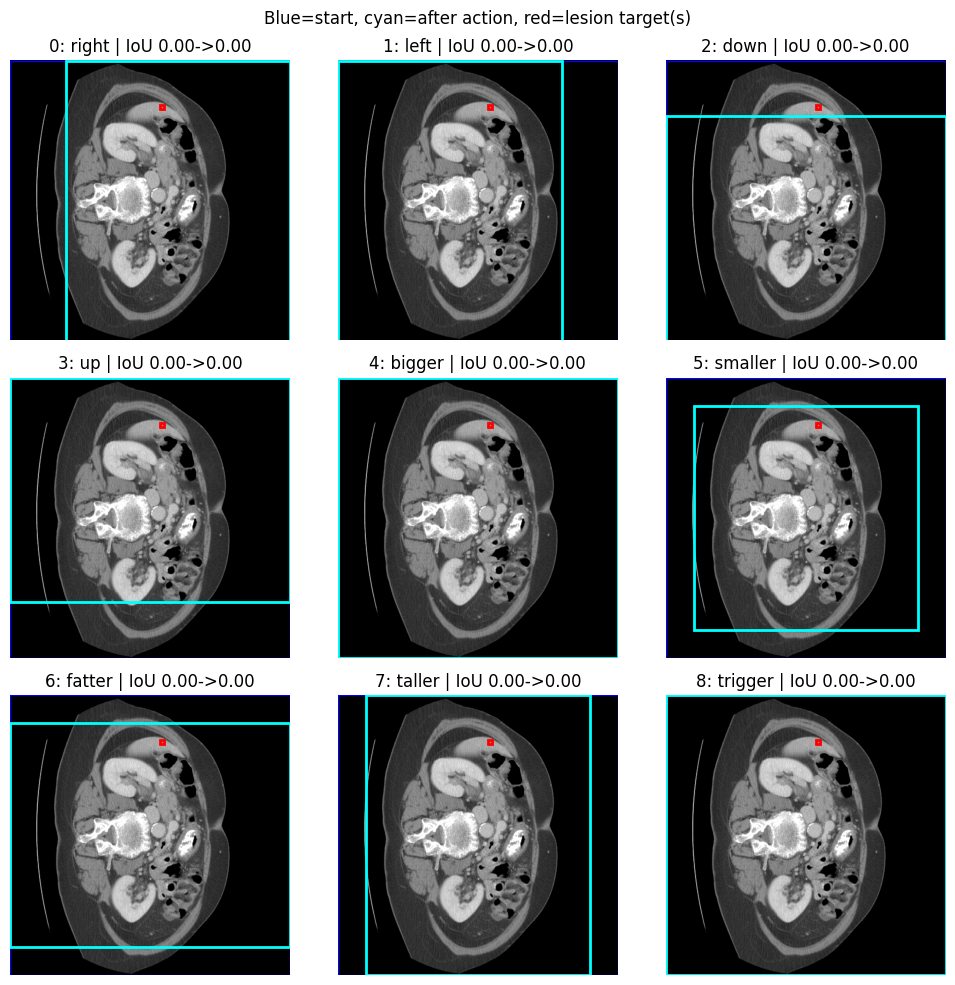

In [7]:

def show_action_panel(record):
    e = Caicedo2DEnv([record], reward_mode=REWARD_MODE)
    e.reset(record=record)
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()
    for a in range(NUM_ACTIONS):
        ax = axes[a]
        ax.imshow(e.image, cmap="gray", vmin=0, vmax=1)
        draw_boxes(ax, e.reward_boxes, color="red", linewidth=2)
        draw_boxes(ax, [e.box], color="blue", linewidth=1)
        new_box = apply_action_2d(e.box, a, e.image.shape, alpha=e.alpha)
        draw_boxes(ax, [new_box], color="cyan", linewidth=2)
        new_iou = max_iou_2d(new_box, e.reward_boxes)
        ax.set_title(f"{a}: {ACTION_NAMES[a]} | IoU {e.prev_iou:.2f}->{new_iou:.2f}")
        ax.axis("off")
    plt.suptitle("Blue=start, cyan=after action, red=lesion target(s)")
    plt.tight_layout()
    plt.show()


show_action_panel(train_records[0])

## Greedy Oracle Check

Verifies that the action space can reach useful lesion boxes.


In [8]:
def greedy_oracle_rollout(record, reward_mode=REWARD_MODE, max_steps=MAX_STEPS,
                          trigger_iou=None, start_box_mode="full"):
    """Greedy 1-step lookahead oracle.

    `trigger_iou` controls when the oracle commits. Use TRIGGER_EVAL_IOU (0.5) to
    certify solvability under the strict eval threshold and to match imitation seeding.
    """
    if trigger_iou is None:
        trigger_iou = TRIGGER_EVAL_IOU
    e = Caicedo2DEnv([record], reward_mode=reward_mode, max_steps=max_steps,
                     start_box_mode=start_box_mode)
    obs, info = e.reset(record=record)
    frames = [{"step": 0, "box": e.box.copy(), "iou": info["iou"], "action": None}]
    done = False
    while not done:
        best_a, best_iou = 0, -1.0
        for a in range(8):
            nb_ = apply_action_2d(e.box, a, e.image.shape, alpha=e.alpha)
            ni = max_iou_2d(nb_, e.reward_boxes)
            if ni > best_iou:
                best_iou, best_a = ni, a
        if e.prev_iou >= trigger_iou:
            best_a = 8
        obs, reward, done, info = e.step(best_a)
        frames.append({"step": e.step_count, "box": e.box.copy(), "iou": info["iou"], "action": best_a})
    return e, frames, info


def oracle_summary(records, n=None, trigger_iou=None, start_box_mode="full"):
    if n is not None:
        records = records[:n]
    results = []
    for rec in records:
        _, frames, info = greedy_oracle_rollout(rec, trigger_iou=trigger_iou,
                                                start_box_mode=start_box_mode)
        results.append({
            "best_iou": max(f["iou"] for f in frames),
            "final_iou": frames[-1]["iou"],
            "triggered": info["triggered"],
            "steps": info["steps"],
        })
    best = np.array([r["best_iou"] for r in results], dtype=np.float32)
    final = np.array([r["final_iou"] for r in results], dtype=np.float32)
    trig = np.array([r["triggered"] for r in results], dtype=np.float32)
    steps = np.array([r["steps"] for r in results], dtype=np.float32)
    return {
        "n": len(results),
        "mean_best_iou": float(best.mean()),
        "mean_final_iou": float(final.mean()),
        "success_best@0.25": float((best >= 0.25).mean()),
        "success_best@0.5": float((best >= 0.5).mean()),
        "trigger_rate": float(trig.mean()),
        "mean_steps": float(steps.mean()),
    }


summary = oracle_summary(val_records, n=min(64, len(val_records)),
                         trigger_iou=TRIGGER_EVAL_IOU, start_box_mode="full")
log_line(json.dumps(summary, indent=2))
assert summary["success_best@0.25"] > 0.0, "Oracle cannot solve even IoU@0.25; fix action design before DQN"

oracle_summary_df = pd.DataFrame([{"split": "validation_sample", **summary}])
display(oracle_summary_df)


,split,n,mean_best_iou,mean_final_iou,success_best@0.25,success_best@0.5,trigger_rate,mean_steps
0,validation_sample,64,0.538635,0.538635,1.0,1.0,1.0,14.90625


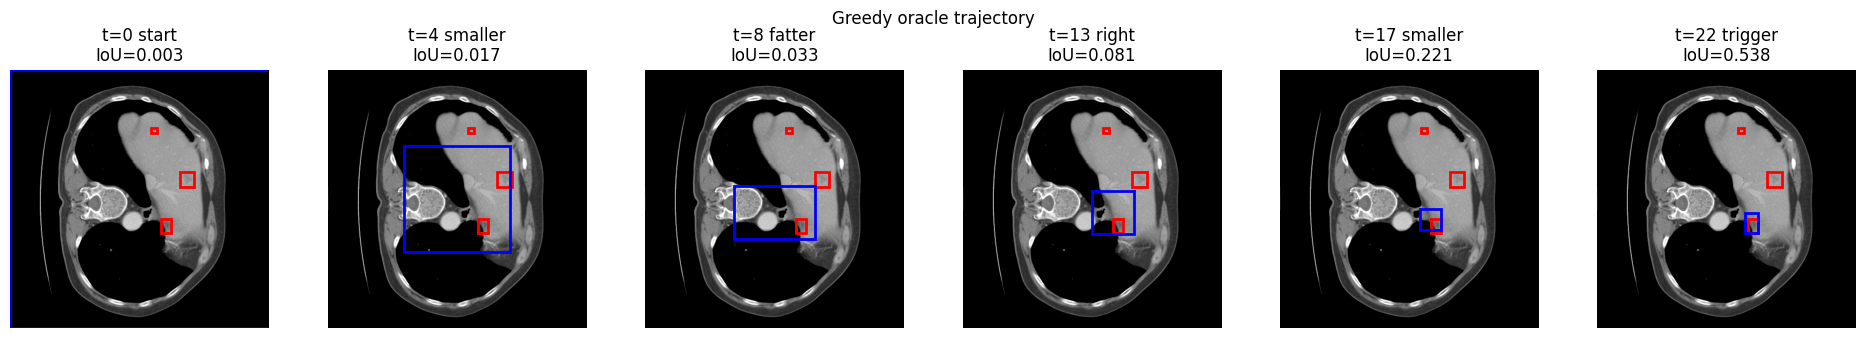

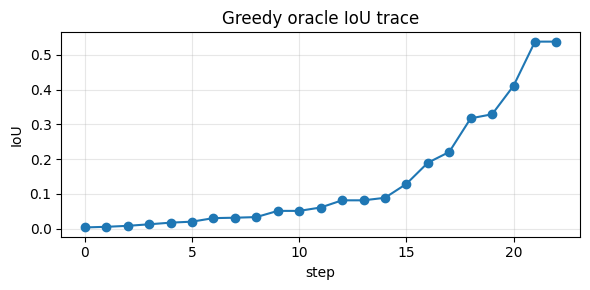

In [9]:

def visualize_rollout(env_obj, frames, title="Rollout"):
    idxs = np.unique(np.linspace(0, len(frames) - 1, min(6, len(frames)), dtype=int))
    fig, axes = plt.subplots(1, len(idxs), figsize=(3.2 * len(idxs), 3.4))
    if len(idxs) == 1:
        axes = [axes]
    for ax, idx in zip(axes, idxs):
        fr = frames[idx]
        ax.imshow(env_obj.image, cmap="gray", vmin=0, vmax=1)
        draw_boxes(ax, env_obj.reward_boxes, color="red", linewidth=2)
        draw_boxes(ax, [fr["box"]], color="blue", linewidth=2)
        action = "start" if fr["action"] is None else ACTION_NAMES[fr["action"]]
        ax.set_title(f"t={fr['step']} {action}\nIoU={fr['iou']:.3f}")
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def best_frame_from_rollout(frames):
    return max(frames, key=lambda f: float(f["iou"]))


def box_area_frac(box, image_shape):
    h, w = int(image_shape[0]), int(image_shape[1])
    x1, y1, x2, y2 = map(float, box)
    area = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    return float(area / max(1.0, h * w))


def is_large_central_box(box, image_shape):
    h, w = int(image_shape[0]), int(image_shape[1])
    x1, y1, x2, y2 = map(float, box)
    cx = 0.5 * (x1 + x2) / max(1.0, w)
    cy = 0.5 * (y1 + y2) / max(1.0, h)
    center_lo = 0.5 - 0.5 * QUAL_CENTER_WINDOW_FRAC
    center_hi = 0.5 + 0.5 * QUAL_CENTER_WINDOW_FRAC
    in_center = center_lo <= cx <= center_hi and center_lo <= cy <= center_hi
    return in_center and box_area_frac(box, image_shape) > QUAL_MAX_BOX_AREA_FRAC


def max_gt_area_frac(env_obj):
    if not env_obj.reward_boxes:
        return 0.0
    return max(box_area_frac(box, env_obj.image.shape) for box in env_obj.reward_boxes)


def qualitative_rollout_score(env_obj, frames):
    best = best_frame_from_rollout(frames)
    area_frac = box_area_frac(best["box"], env_obj.image.shape)
    gt_area_frac = max_gt_area_frac(env_obj)
    score = float(best["iou"]) - 0.25 * area_frac - 0.5 * gt_area_frac
    if is_large_central_box(best["box"], env_obj.image.shape):
        score -= 1.0
    if gt_area_frac > QUAL_MAX_GT_AREA_FRAC:
        score -= 1.0
    return score
oracle_env, oracle_frames, oracle_info = greedy_oracle_rollout(val_records[0])
visualize_rollout(oracle_env, oracle_frames, "Greedy oracle trajectory")
plt.figure(figsize=(6, 3))
plt.plot([f["iou"] for f in oracle_frames], marker="o")
plt.xlabel("step")
plt.ylabel("IoU")
plt.title("Greedy oracle IoU trace")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visual Encoder

Loads VGG16 features and applies the configured encoder-freezing policy.


In [10]:
class VGG16PartialFineTune(nn.Module):
    """VGG16 encoder with a frozen conv stack and optional fc6-only adaptation.

    Backbone (frozen, ~7.6M params): features[0:24]
        Through conv4_3 + maxpool. Output shape (B, 512, 14, 14).
        Ten convs + four maxpools. Provides stable ImageNet edge/texture features.

    Head path: features[24:31] + avgpool + flatten + fc6
        conv5_1 -> conv5_2 -> conv5_3 -> maxpool (output (B, 512, 7, 7))
        -> adaptive_avgpool to (B, 512, 7, 7)
        -> flatten to (B, 25088)
        -> fc6 Linear(25088, 4096) -> 4096-d feature.
        With ENCODER_TRAIN_FC6_ONLY=True, conv5 is frozen and only fc6 is trained.

    Forward modes:
      .backbone_forward(crop): no-grad pass through frozen layers; returns conv4 features.
        Used during rollout collection where we don't backprop through the encoder.
      .head_forward(conv4_feat): grad-aware pass through trainable layers; returns 4096-d.
        Used during both collection (no_grad outer context) and PPO update (grad enabled).
      .full_forward(crop): convenience wrapper for evaluation; matches old API.
    """

    def __init__(self, pretrained=True, freeze_backbone=True):
        super().__init__()
        if models is None:
            raise RuntimeError("torchvision is required")
        try:
            weights = models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None
            vgg = models.vgg16(weights=weights)
            self.pretrained = pretrained
        except Exception as e:
            log_line(f"WARNING: pretrained VGG16 load failed: {e}; falling back to random weights")
            vgg = models.vgg16(weights=None)
            self.pretrained = False


        self.backbone = vgg.features[:24]

        self.head_conv = vgg.features[24:]
        self.avgpool = vgg.avgpool
        self.fc6 = vgg.classifier[0]

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()
        if ENCODER_TRAIN_FC6_ONLY:
            for p in self.head_conv.parameters():
                p.requires_grad = False
            self.head_conv.eval()

        if not ENCODER_UPDATE_DURING_PPO:
            for p in self.parameters():
                p.requires_grad = False
            self.eval()

        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def train(self, mode=True):

        super().train(mode)
        self.backbone.eval()
        if ENCODER_TRAIN_FC6_ONLY:
            self.head_conv.eval()
        return self

    def _normalize(self, crop_batch):

        x = crop_batch.repeat(1, 3, 1, 1)
        return (x - self.mean) / self.std

    def backbone_forward(self, crop_batch):
        """Returns conv4 features (B, 512, 14, 14). Always no-grad — backbone is frozen."""
        x = self._normalize(crop_batch)
        with torch.no_grad():
            return self.backbone(x)

    def head_forward(self, conv4_feat):
        """Head pass. Gradients flow only when encoder adaptation is enabled."""
        no_grad_head = (not ENCODER_UPDATE_DURING_PPO) or ENCODER_TRAIN_FC6_ONLY
        if no_grad_head:
            with torch.no_grad():
                x = self.head_conv(conv4_feat)
        else:
            x = self.head_conv(conv4_feat)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        if ENCODER_UPDATE_DURING_PPO:
            return self.fc6(x)
        with torch.no_grad():
            return self.fc6(x)

    def full_forward(self, crop_batch):
        """Convenience: full encoder pass with grad on the head only."""
        with torch.no_grad():
            backbone_out = self.backbone(self._normalize(crop_batch))
        return self.head_forward(backbone_out)

    def trainable_parameters(self):
        return [p for p in self.parameters() if p.requires_grad]


feature_extractor = VGG16PartialFineTune(pretrained=True, freeze_backbone=ENCODER_FREEZE_BACKBONE).to(DEVICE)
n_frozen = sum(p.numel() for p in feature_extractor.parameters() if not p.requires_grad)
n_trainable = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
log_line(f"VGG16 partial fine-tune ready")
log_line(f"  pretrained={feature_extractor.pretrained}")
log_line(f"  frozen params (conv stack): {n_frozen:>12,}")
log_line(f"  trainable params ({'frozen encoder' if not ENCODER_UPDATE_DURING_PPO else ('fc6 only' if ENCODER_TRAIN_FC6_ONLY else 'conv5+fc6')}): {n_trainable:>10,}")


with torch.inference_mode():
    dummy_crop = torch.zeros(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    dummy_conv4 = feature_extractor.backbone_forward(dummy_crop)
    dummy_feat = feature_extractor.head_forward(dummy_conv4)
log_line(f"  conv4 shape={tuple(dummy_conv4.shape)} (expected (2,512,14,14))")
log_line(f"  feature shape={tuple(dummy_feat.shape)} (expected (2,4096))")
assert dummy_conv4.shape == (2, 512, 14, 14)
assert dummy_feat.shape == (2, 4096)

encoder_summary_df = pd.DataFrame([
    {"metric": "pretrained", "value": feature_extractor.pretrained},
    {"metric": "frozen_parameters", "value": n_frozen},
    {"metric": "trainable_parameters", "value": n_trainable},
    {"metric": "conv4_shape", "value": str(tuple(dummy_conv4.shape))},
    {"metric": "feature_shape", "value": str(tuple(dummy_feat.shape))},
])
display(encoder_summary_df)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 235MB/s]


,metric,value
0,pretrained,True
1,frozen_parameters,117479232
2,trainable_parameters,0
3,conv4_shape,"(2, 512, 14, 14)"
4,feature_shape,"(2, 4096)"


## PPO Model and Update

Defines the actor-critic network, rollout buffer, and clipped PPO update.


In [11]:
class ActorCritic(nn.Module):
    """Shared-torso actor-critic over encoder features, action history, and box geometry."""

    def __init__(self, feature_dim=4096, history_dim=HISTORY_LEN * NUM_ACTIONS,
                 box_dim=BOX_FEATURE_DIM, hidden=1024, n_actions=NUM_ACTIONS):
        super().__init__()
        self.torso = nn.Sequential(
            nn.Linear(feature_dim + history_dim + box_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
        )
        self.policy_head = nn.Linear(hidden, n_actions)
        self.value_head = nn.Linear(hidden, 1)

        for m in self.torso:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=math.sqrt(2.0))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)
        nn.init.zeros_(self.policy_head.bias)
        nn.init.orthogonal_(self.value_head.weight, gain=1.0)
        nn.init.zeros_(self.value_head.bias)

    def forward(self, features, history, box_features):
        x = torch.cat([features, history, box_features], dim=1)
        h = self.torso(x)
        return self.policy_head(h), self.value_head(h).squeeze(-1)

    def get_action_and_value(self, features, history, box_features, action=None):
        logits, value = self.forward(features, history, box_features)
        dist = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        return action, log_prob, entropy, value


class RolloutBuffer:
    """v5 buffer: stores raw crops + history so the encoder can be re-run during PPO updates."""

    def __init__(self, n_steps, crop_size, history_dim, box_dim, device):
        self.n_steps = n_steps
        self.device = device

        self.crops = torch.zeros((n_steps, 1, crop_size, crop_size), device=device)
        self.hists = torch.zeros((n_steps, history_dim), device=device)
        self.box_feats = torch.zeros((n_steps, box_dim), device=device)
        self.actions = torch.zeros((n_steps,), dtype=torch.long, device=device)
        self.log_probs = torch.zeros((n_steps,), device=device)
        self.values = torch.zeros((n_steps,), device=device)
        self.rewards = torch.zeros((n_steps,), device=device)
        self.ious = torch.zeros((n_steps,), device=device)
        self.dones = torch.zeros((n_steps,), device=device)
        self.action_masks = torch.ones((n_steps, NUM_ACTIONS), dtype=torch.bool, device=device)
        self.advantages = torch.zeros((n_steps,), device=device)
        self.returns = torch.zeros((n_steps,), device=device)
        self.ptr = 0

    def add(self, crop, hist, box_feat, action, log_prob, value, reward, iou, done, action_mask):
        i = self.ptr
        self.crops[i] = crop.squeeze(0)
        self.hists[i] = hist.squeeze(0)
        self.box_feats[i] = box_feat.squeeze(0)
        self.actions[i] = int(action)
        self.log_probs[i] = float(log_prob)
        self.values[i] = float(value)
        self.rewards[i] = float(reward)
        self.ious[i] = float(iou)
        self.dones[i] = float(done)
        self.action_masks[i] = torch.as_tensor(action_mask, dtype=torch.bool, device=self.device)
        self.ptr += 1

    def is_full(self):
        return self.ptr >= self.n_steps

    def reset(self):
        self.ptr = 0

    def compute_gae(self, last_value, gamma=GAMMA, gae_lambda=GAE_LAMBDA):
        last_gae = 0.0
        n = self.ptr
        for t in reversed(range(n)):
            if t == n - 1:
                next_value = last_value
                next_nonterminal = 1.0 - self.dones[t].item()
            else:
                next_value = self.values[t + 1].item()
                next_nonterminal = 1.0 - self.dones[t].item()
            delta = self.rewards[t].item() + gamma * next_value * next_nonterminal - self.values[t].item()
            last_gae = delta + gamma * gae_lambda * next_nonterminal * last_gae
            self.advantages[t] = last_gae
        self.returns[:n] = self.advantages[:n] + self.values[:n]


def encode_minibatch(crops):
    """Encode crops. The encoder is frozen unless explicitly re-enabled."""
    if not ENCODER_UPDATE_DURING_PPO:
        with torch.no_grad():
            return feature_extractor.full_forward(crops)
    conv4 = feature_extractor.backbone_forward(crops)
    return feature_extractor.head_forward(conv4)


def action_mask_from_env(env_obj, previous_action=None):
    mask = np.zeros(NUM_ACTIONS, dtype=np.bool_)
    for action in env_obj.available_actions(previous_action):
        mask[int(action)] = True
    if not mask.any():
        mask[:] = True
    return mask


def apply_action_mask_to_logits(logits, action_mask):
    if not USE_ACTION_MASK:
        return logits
    return logits.masked_fill(~action_mask.bool(), -1e9)


def ppo_update(agent, policy_optimizer, encoder_optimizer, buffer,
               n_epochs=N_PPO_EPOCHS, minibatch_size=MINIBATCH_SIZE,
               clip_coef=CLIP_COEF, vf_coef=VF_COEF, ent_coef=ENT_COEF,
               normalize_advantages=NORMALIZE_ADVANTAGES,
               policy_max_grad=MAX_GRAD_NORM, encoder_max_grad=ENCODER_MAX_GRAD_NORM,
               target_kl=TARGET_KL, trigger_aux_coef=TRIGGER_AUX_COEF,
               clip_vloss=CLIP_VLOSS, value_clip_coef=VALUE_CLIP_COEF):
    """PPO update with two optimizers. Each minibatch re-encodes crops -> features
    so gradients flow into the encoder head. KL early-stop unchanged from v4."""
    n = buffer.ptr
    indices = np.arange(n)
    losses = {"policy": [], "value": [], "entropy": [], "trigger_aux": [],
              "approx_kl": [], "clipfrac": [], "encoder_grad_norm": []}
    epochs_done = 0
    early_stopped = False

    for epoch in range(n_epochs):
        np.random.shuffle(indices)
        epoch_kls = []
        for start in range(0, n, minibatch_size):
            mb = indices[start:start + minibatch_size]
            mb_t = torch.as_tensor(mb, dtype=torch.long, device=buffer.device)

            mb_crops = buffer.crops[mb_t]
            mb_hist = buffer.hists[mb_t]
            mb_box_feat = buffer.box_feats[mb_t]
            mb_actions = buffer.actions[mb_t]
            mb_old_logp = buffer.log_probs[mb_t]
            mb_returns = buffer.returns[mb_t]
            mb_adv = buffer.advantages[mb_t]
            mb_ious = buffer.ious[mb_t]
            mb_action_masks = buffer.action_masks[mb_t]

            if normalize_advantages and mb_adv.numel() > 1:
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)


            mb_feat = encode_minibatch(mb_crops)
            logits, new_value = agent(mb_feat, mb_hist, mb_box_feat)
            masked_logits = apply_action_mask_to_logits(logits, mb_action_masks)
            dist = Categorical(logits=masked_logits)
            new_logp = dist.log_prob(mb_actions)
            entropy = dist.entropy()

            log_ratio = new_logp - mb_old_logp
            ratio = log_ratio.exp()
            surr1 = ratio * mb_adv
            surr2 = torch.clamp(ratio, 1.0 - clip_coef, 1.0 + clip_coef) * mb_adv
            policy_loss = -torch.min(surr1, surr2).mean()
            if clip_vloss:
                old_value = buffer.values[mb_t]
                value_clipped = old_value + torch.clamp(
                    new_value - old_value, -value_clip_coef, value_clip_coef,
                )
                value_loss_unclipped = (new_value - mb_returns).pow(2)
                value_loss_clipped = (value_clipped - mb_returns).pow(2)
                value_loss = 0.5 * torch.max(value_loss_unclipped, value_loss_clipped).mean()
            else:
                value_loss = 0.5 * (new_value - mb_returns).pow(2).mean()
            entropy_bonus = entropy.mean()
            trigger_aux_loss = logits.new_tensor(0.0)
            if USE_TRIGGER_AUX_LOSS and trigger_aux_coef > 0.0:
                aux_terms = []
                pos_mask = mb_ious >= TRIGGER_AUX_POS_IOU
                neg_mask = mb_ious <= TRIGGER_AUX_NEG_IOU
                if pos_mask.any():
                    pos_logits = masked_logits[pos_mask]
                    pos_targets = torch.full(
                        (pos_logits.shape[0],), 8, dtype=torch.long, device=pos_logits.device
                    )
                    pos_ce = F.cross_entropy(pos_logits, pos_targets)
                    pos_margin = F.relu(
                        TRIGGER_AUX_MARGIN + pos_logits[:, :8].max(dim=1).values - pos_logits[:, 8]
                    ).mean()
                    aux_terms.append(TRIGGER_AUX_POS_WEIGHT * (pos_ce + pos_margin))
                if neg_mask.any():
                    neg_loss = F.binary_cross_entropy_with_logits(
                        masked_logits[neg_mask, 8], torch.zeros_like(masked_logits[neg_mask, 8])
                    )
                    aux_terms.append(TRIGGER_AUX_NEG_WEIGHT * neg_loss)
                if aux_terms:
                    trigger_aux_loss = torch.stack(aux_terms).sum()

            loss = policy_loss + vf_coef * value_loss - ent_coef * entropy_bonus
            loss = loss + trigger_aux_coef * trigger_aux_loss


            policy_optimizer.zero_grad(set_to_none=True)
            if encoder_optimizer is not None:
                encoder_optimizer.zero_grad(set_to_none=True)
            loss.backward()


            policy_gn = torch.nn.utils.clip_grad_norm_(agent.parameters(), policy_max_grad)
            encoder_params = feature_extractor.trainable_parameters()
            if encoder_optimizer is not None and encoder_params:
                enc_gn = torch.nn.utils.clip_grad_norm_(encoder_params, encoder_max_grad)
            else:
                enc_gn = torch.tensor(0.0, device=buffer.device)

            policy_optimizer.step()
            if encoder_optimizer is not None:
                encoder_optimizer.step()

            with torch.no_grad():
                approx_kl = (-log_ratio).mean().item()
                clipfrac = ((ratio - 1.0).abs() > clip_coef).float().mean().item()

            losses["policy"].append(policy_loss.item())
            losses["value"].append(value_loss.item())
            losses["entropy"].append(entropy_bonus.item())
            losses["trigger_aux"].append(float(trigger_aux_loss.item()))
            losses["approx_kl"].append(approx_kl)
            losses["clipfrac"].append(clipfrac)
            losses["encoder_grad_norm"].append(float(enc_gn.item()) if hasattr(enc_gn, "item") else float(enc_gn))
            epoch_kls.append(approx_kl)

        epochs_done += 1
        if target_kl is not None and len(epoch_kls) > 0 and float(np.mean(epoch_kls)) > target_kl:
            early_stopped = True
            break

    out = {k: float(np.mean(v)) if v else float("nan") for k, v in losses.items()}
    out["epochs_done"] = int(epochs_done)
    out["early_stopped"] = bool(early_stopped)
    return out


agent = ActorCritic().to(DEVICE)
policy_optimizer = torch.optim.Adam(agent.parameters(), lr=LR_PPO, eps=1e-5)
encoder_params = feature_extractor.trainable_parameters()
encoder_optimizer = (
    torch.optim.Adam(encoder_params, lr=LR_ENCODER, eps=1e-5)
    if encoder_params and LR_ENCODER > 0.0 else None
)


def box_features_from_obs(obs):
    x1, y1, x2, y2 = obs["box"].astype(np.float32)
    h, w = obs["image_shape"].astype(np.float32)
    bw = max(1.0, x2 - x1)
    bh = max(1.0, y2 - y1)
    cx = x1 + 0.5 * bw
    cy = y1 + 0.5 * bh
    return np.array([
        x1 / w, y1 / h, x2 / w, y2 / h,
        cx / w, cy / h, bw / w, bh / h,
    ], dtype=np.float32)


def obs_to_buffer_inputs(obs):
    """v5: returns crop, history, and normalized box geometry tensors on device."""
    crop = torch.from_numpy(obs["crop"]).unsqueeze(0).to(DEVICE)
    hist = torch.from_numpy(obs["history"]).unsqueeze(0).float().to(DEVICE)
    box_feat = torch.from_numpy(box_features_from_obs(obs)).unsqueeze(0).float().to(DEVICE)
    return crop, hist, box_feat


def encode_for_action(crop, hist, box_feat):
    """Rollout-time encoding: no-grad full encoder pass + actor-critic forward.
    Returns logits (1,9), value (1,) — both used for action sampling, not for loss."""
    with torch.no_grad():
        feat = feature_extractor.full_forward(crop)
        logits, value = agent(feat, hist, box_feat)
    return logits, value


def obs_to_tensors(obs):
    """Compat shim: returns encoded crop, history, and box geometry tensors.
    Used by evaluate_ppo and BC dataset collection (which don't need encoder gradients)."""
    crop, hist, box_feat = obs_to_buffer_inputs(obs)
    with torch.no_grad():
        feat = feature_extractor.full_forward(crop)
    return feat, hist, box_feat


log_line(agent)
n_policy = sum(p.numel() for p in agent.parameters() if p.requires_grad)
n_encoder = sum(p.numel() for p in feature_extractor.trainable_parameters())
log_line(f"policy params (trainable): {n_policy:>13,}  | optimizer LR={LR_PPO}")
log_line(f"encoder params (trainable): {n_encoder:>12,}  | optimizer LR={LR_ENCODER} | optimizer={encoder_optimizer is not None}")
log_line(f"total trainable params: {n_policy + n_encoder:>17,}")

model_summary_df = pd.DataFrame([
    {"component": "policy", "trainable_parameters": n_policy, "learning_rate": LR_PPO},
    {"component": "encoder", "trainable_parameters": n_encoder, "learning_rate": LR_ENCODER},
    {"component": "total", "trainable_parameters": n_policy + n_encoder, "learning_rate": None},
])
display(model_summary_df)


,component,trainable_parameters,learning_rate
0,policy,5355530,0.00003
1,encoder,0,0.00000
2,total,5355530,NaN


## Evaluation Protocol

Computes standardized final, best, trigger, timeout, and step metrics.


In [12]:
def masked_eval_logits(logits, env_obj, previous_action=None):
    if USE_ACTION_MASK:
        mask = torch.as_tensor(
            action_mask_from_env(env_obj, previous_action), dtype=torch.bool, device=logits.device,
        ).unsqueeze(0)
        return apply_action_mask_to_logits(logits, mask)
    return logits


def action_from_masked_logits(masked_logits):
    greedy_action = int(torch.argmax(masked_logits, dim=1).item())
    if EVAL_TRIGGER_PROB is not None and greedy_action != 8:
        probs = torch.softmax(masked_logits, dim=1)
        if float(probs[0, 8].item()) >= EVAL_TRIGGER_PROB:
            return 8
    return greedy_action


def masked_policy_argmax(logits, env_obj, previous_action=None):
    return action_from_masked_logits(masked_eval_logits(logits, env_obj, previous_action))


def stop_confidence_from_logits(masked_logits, value):
    stop_logit = masked_logits[0, 8]
    best_move_logit = torch.max(masked_logits[0, :8])
    stop_margin = stop_logit - best_move_logit
    stop_prob = torch.softmax(masked_logits, dim=1)[0, 8]
    state_value = value.reshape(-1)[0]
    mode = REPORT_TIMEOUT_BOX_SELECTION
    if mode == "stop_prob":
        score = stop_prob
    elif mode == "value":
        score = state_value
    else:
        score = stop_margin
    return {
        "report_score": float(score.detach().cpu().item()),
        "report_stop_prob": float(stop_prob.detach().cpu().item()),
        "report_stop_margin": float(stop_margin.detach().cpu().item()),
        "report_state_value": float(state_value.detach().cpu().item()),
    }


def best_confidence_frame_from_rollout(frames):
    scored = [f for f in frames if f.get("report_score") is not None and np.isfinite(f.get("report_score"))]
    if not scored:
        return frames[-1]
    return max(scored, key=lambda f: float(f["report_score"]))


def reported_result_from_rollout(info, frames):
    terminal = frames[-1]
    raw_final_iou = float(info["iou"])
    report_frame = terminal
    report_source = "terminal_trigger" if info["triggered"] else "terminal_timeout"
    fallback_reported = False

    if info["timed_out"] and REPORT_BEST_ON_TIMEOUT:
        report_frame = best_confidence_frame_from_rollout(frames)
        report_source = "stop_confidence_timeout"
        fallback_reported = int(report_frame.get("step", terminal.get("step", info["steps"]))) != int(terminal.get("step", info["steps"]))
    elif info["triggered"] and REPORT_BEST_ON_TRIGGER:
        report_frame = best_confidence_frame_from_rollout(frames)
        report_source = "stop_confidence_trigger"
        fallback_reported = int(report_frame.get("step", terminal.get("step", info["steps"]))) != int(terminal.get("step", info["steps"]))

    return {
        "final_iou": float(report_frame.get("iou", raw_final_iou)),
        "raw_final_iou": raw_final_iou,
        "report_step": int(report_frame.get("step", info["steps"])),
        "report_source": report_source,
        "fallback_reported": bool(fallback_reported),
        "report_score": report_frame.get("report_score", None),
        "report_stop_prob": report_frame.get("report_stop_prob", None),
        "report_stop_margin": report_frame.get("report_stop_margin", None),
        "report_state_value": report_frame.get("report_state_value", None),
    }


def annotate_frame_for_reporting(frames, obs, env_obj, previous_action=None):
    feat, hist, box_feat = obs_to_tensors(obs)
    with torch.no_grad():
        logits, value = agent(feat, hist, box_feat)
        masked_logits = masked_eval_logits(logits, env_obj, previous_action)
    frames[-1].update(stop_confidence_from_logits(masked_logits, value))
    return masked_logits


def multistart_report_area_frac(box, image_shape):
    h, w = int(image_shape[0]), int(image_shape[1])
    x1, y1, x2, y2 = np.asarray(box, dtype=np.float32)
    area = max(0.0, float(x2 - x1)) * max(0.0, float(y2 - y1))
    return float(area / max(1.0, float(h * w)))


def multistart_start_boxes(h, w, max_starts=MULTISTART_NUM_STARTS):
    """Deterministic deployable starts: full image, quadrants, then central crops."""
    h, w = int(h), int(w)
    mx, my = w // 2, h // 2
    boxes = [
        [0, 0, w, h],
        [0, 0, mx, my],
        [mx, 0, w, my],
        [0, my, mx, h],
        [mx, my, w, h],
    ]

    px, py = int(0.10 * w), int(0.10 * h)
    boxes.append([px, py, w - px, h - py])

    sw, sh = int(0.40 * w), int(0.40 * h)
    cx, cy = w // 2, h // 2
    boxes.append([cx - sw // 2, cy - sh // 2, cx + sw // 2, cy + sh // 2])

    clipped, seen = [], set()
    for b in boxes:
        cb = clip_box_2d(b, h, w)
        key = tuple(int(v) for v in cb)
        if key in seen:
            continue
        clipped.append(cb)
        seen.add(key)
        if len(clipped) >= int(max_starts):
            break
    return clipped


def reset_env_to_start_box(env_obj, start_box):
    env_obj.box = clip_box_2d(start_box, env_obj.h, env_obj.w).astype(np.int64)
    env_obj.history = np.zeros((HISTORY_LEN, NUM_ACTIONS), dtype=np.float32)
    env_obj.step_count = 0
    env_obj.prev_iou = max_iou_2d(env_obj.box, env_obj.reward_boxes)
    env_obj.best_iou = env_obj.prev_iou
    env_obj.last_action = None
    env_obj.recent_actions = deque(maxlen=SHAPE_REPEAT_WINDOW)
    return env_obj._obs(), env_obj._info(triggered=False, timed_out=False)


def report_candidate_frames(frames, image_shape):
    candidates = []
    for frame in frames:
        score = frame.get("report_score", None)
        if score is None or not np.isfinite(score):
            continue
        if int(frame.get("step", 0)) < int(MULTISTART_MIN_REPORT_STEP):
            continue
        if multistart_report_area_frac(frame["box"], image_shape) > float(MULTISTART_MAX_REPORT_AREA_FRAC):
            continue
        candidates.append(frame)
    return candidates


def best_multistart_confidence_frame(runs):
    scored = []
    fallback_scored = []
    for run in runs:
        env_obj = run["env"]
        for frame in run["frames"]:
            score = frame.get("report_score", None)
            if score is None or not np.isfinite(score):
                continue
            fallback_scored.append((float(score), run, frame))
        for frame in report_candidate_frames(run["frames"], env_obj.image.shape):
            scored.append((float(frame["report_score"]), run, frame))
    pool = scored if scored else fallback_scored
    if not pool:
        run = runs[0]
        return run, run["frames"][-1]
    _, selected_run, selected_frame = max(pool, key=lambda item: item[0])
    return selected_run, selected_frame


def ppo_result_from_rollout(env_obj, info, frames, reversals, start_index=0, num_starts=1):
    best_frame = best_frame_from_rollout(frames)
    reported = reported_result_from_rollout(info, frames)
    raw_final_iou = reported["raw_final_iou"]
    final_iou = float(reported["final_iou"])
    return {
        "final_iou": final_iou,
        "raw_final_iou": float(raw_final_iou),
        "best_iou": float(info["best_iou"]),
        "best_step": int(best_frame["step"]),
        "triggered": bool(info["triggered"]),
        "good_trigger": bool(info["triggered"] and raw_final_iou >= TRIGGER_EVAL_IOU),
        "bad_trigger": bool(info["triggered"] and raw_final_iou < TRIGGER_EVAL_IOU),
        "timed_out": bool(info["timed_out"]),
        "steps": int(info["steps"]),
        "report_step": int(reported["report_step"]),
        "report_source": reported["report_source"],
        "fallback_reported": bool(reported["fallback_reported"]),
        "report_score": reported["report_score"],
        "report_stop_prob": reported["report_stop_prob"],
        "report_stop_margin": reported["report_stop_margin"],
        "report_state_value": reported["report_state_value"],
        "reversals": int(reversals),
        "vid": int(info["vid"]),
        "slice": int(info["slice"]),
        "diameter_mm": float(info["diameter_mm"]),
        "num_starts": int(num_starts),
        "selected_start_index": int(start_index),
        "single_start_final_iou": final_iou,
        "single_start_best_iou": float(info["best_iou"]),
        "multistart_gain_iou": 0.0,
    }


def rollout_ppo_single_start(rec, start_box=None, start_index=0, num_starts=1):
    e = Caicedo2DEnv([rec], reward_mode=REWARD_MODE, start_box_mode=START_BOX_MODE_EVAL)
    obs, info = e.reset(record=rec)
    if start_box is not None:
        obs, info = reset_env_to_start_box(e, start_box)

    frames = [{
        "step": 0,
        "box": e.box.copy(),
        "iou": info["iou"],
        "action": None,
        "start_index": int(start_index),
    }]
    prev_a, reversals = None, 0
    done = False
    while not done:
        masked_logits = annotate_frame_for_reporting(frames, obs, e, prev_a)
        action = action_from_masked_logits(masked_logits)
        if prev_a is not None and action < 8 and OPPOSITE.get(prev_a) == action:
            reversals += 1
        prev_a = action
        obs, reward, done, info = e.step(action)
        frames.append({
            "step": e.step_count,
            "box": e.box.copy(),
            "iou": info["iou"],
            "action": action,
            "start_index": int(start_index),
        })

    if frames[-1].get("report_score") is None:
        annotate_frame_for_reporting(frames, obs, e, prev_a)

    result = ppo_result_from_rollout(e, info, frames, reversals, start_index=start_index, num_starts=num_starts)
    return {"result": result, "env": e, "frames": frames, "info": info, "reversals": reversals}


def evaluate_ppo_record_multistart(rec):
    probe = Caicedo2DEnv([rec], reward_mode=REWARD_MODE, start_box_mode=START_BOX_MODE_EVAL)
    probe.reset(record=rec)
    start_boxes = multistart_start_boxes(probe.h, probe.w)

    runs = []
    for idx, start_box in enumerate(start_boxes):
        runs.append(rollout_ppo_single_start(rec, start_box=start_box, start_index=idx, num_starts=len(start_boxes)))

    base = dict(runs[0]["result"])
    selected_run, selected_frame = best_multistart_confidence_frame(runs)
    selected_frame["selected_multistart_report"] = True

    all_frames = [frame for run in runs for frame in run["frames"]]
    multi_best_frame = best_frame_from_rollout(all_frames)
    selected_iou = float(selected_frame.get("iou", base["final_iou"]))

    base.update({
        "final_iou": selected_iou,
        "best_iou": float(multi_best_frame.get("iou", base["best_iou"])),
        "best_step": int(multi_best_frame.get("step", base["best_step"])),
        "report_step": int(selected_frame.get("step", base["report_step"])),
        "report_source": "multistart_stop_confidence",
        "fallback_reported": bool(
            int(selected_frame.get("start_index", 0)) != 0
            or int(selected_frame.get("step", -1)) != int(runs[0]["result"]["report_step"])
        ),
        "report_score": selected_frame.get("report_score", None),
        "report_stop_prob": selected_frame.get("report_stop_prob", None),
        "report_stop_margin": selected_frame.get("report_stop_margin", None),
        "report_state_value": selected_frame.get("report_state_value", None),
        "num_starts": int(len(start_boxes)),
        "selected_start_index": int(selected_frame.get("start_index", 0)),
        "single_start_final_iou": float(runs[0]["result"]["final_iou"]),
        "single_start_best_iou": float(runs[0]["result"]["best_iou"]),
        "multistart_gain_iou": float(selected_iou - runs[0]["result"]["final_iou"]),
    })
    return base, selected_run["env"], selected_run["frames"]


def evaluate_ppo(records, n=None, render_one=False, multistart=False):
    if n is not None:
        records = records[:n]
    results = []
    example = None
    example_score = -1.0
    agent.eval()
    feature_extractor.eval()
    use_multistart = bool(multistart and USE_MULTISTART_REPORTING)
    for rec in records:
        if use_multistart:
            result, e, frames = evaluate_ppo_record_multistart(rec)
        else:
            run = rollout_ppo_single_start(rec)
            result, e, frames = run["result"], run["env"], run["frames"]
        results.append(result)
        if render_one:
            display_score = max(float(f["iou"]) for f in frames)
            if display_score > example_score:
                example = (e, frames)
                example_score = display_score
    return summarize_eval(results), example


def evaluate_random(records, n=None):
    if n is not None:
        records = records[:n]
    results = []
    for rec in records:
        e = Caicedo2DEnv([rec], reward_mode=REWARD_MODE, start_box_mode=START_BOX_MODE_EVAL)
        obs, info = e.reset(record=rec)
        done = False
        while not done:
            action = int(random.choice(e.available_actions(e.last_action)))
            obs, reward, done, info = e.step(action)
        raw_final_iou = float(info["iou"])
        results.append({
            "final_iou": raw_final_iou,
            "raw_final_iou": raw_final_iou,
            "best_iou": float(info["best_iou"]),
            "triggered": bool(info["triggered"]),
            "good_trigger": bool(info["triggered"] and raw_final_iou >= TRIGGER_EVAL_IOU),
            "bad_trigger": bool(info["triggered"] and raw_final_iou < TRIGGER_EVAL_IOU),
            "timed_out": bool(info["timed_out"]),
            "steps": int(info["steps"]),
            "report_step": int(info["steps"]),
            "report_source": "terminal_trigger" if info["triggered"] else "terminal_timeout",
            "fallback_reported": False,
            "report_score": None,
            "report_stop_prob": None,
            "report_stop_margin": None,
            "report_state_value": None,
            "reversals": 0,
        })
    return summarize_eval(results)


def metric_array(results, key, default=np.nan):
    return np.array([
        default if r.get(key, default) is None else r.get(key, default)
        for r in results
    ], dtype=np.float32)


def finite_mean(values):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]
    return float(values.mean()) if len(values) else 0.0


def summarize_eval(results):
    if not results:
        return {"n": 0, "report_protocol": REPORT_PROTOCOL_NAME}
    final_iou = metric_array(results, "final_iou")
    raw_final_iou = metric_array(results, "raw_final_iou")
    best_iou = metric_array(results, "best_iou")
    trig = metric_array(results, "triggered", 0.0)
    good_trig = metric_array(results, "good_trigger", 0.0)
    bad_trig = metric_array(results, "bad_trigger", 0.0)
    timeout = metric_array(results, "timed_out", 0.0)
    fallback = metric_array(results, "fallback_reported", 0.0)
    steps = metric_array(results, "steps")
    report_steps = metric_array(results, "report_step")
    rev = metric_array(results, "reversals")
    stop_prob = metric_array(results, "report_stop_prob")
    stop_margin = metric_array(results, "report_stop_margin")
    state_value = metric_array(results, "report_state_value")
    num_starts = metric_array(results, "num_starts")
    selected_start = metric_array(results, "selected_start_index")
    single_start_final = metric_array(results, "single_start_final_iou")
    single_start_best = metric_array(results, "single_start_best_iou")
    multistart_gain = metric_array(results, "multistart_gain_iou")
    finite_gain = multistart_gain[np.isfinite(multistart_gain)]
    triggered_iou = raw_final_iou[trig.astype(bool)]
    n_triggered = float(trig.sum())
    return {
        "n": len(results),
        "report_protocol": REPORT_PROTOCOL_NAME,
        "report_timeout_box_selection": REPORT_TIMEOUT_BOX_SELECTION,
        "use_multistart_reporting": USE_MULTISTART_REPORTING,
        "multistart_num_starts_config": MULTISTART_NUM_STARTS,
        "multistart_min_report_step": MULTISTART_MIN_REPORT_STEP,
        "multistart_max_report_area_frac": MULTISTART_MAX_REPORT_AREA_FRAC,
        "mean_final_iou": float(final_iou.mean()),
        "mean_raw_final_iou": float(raw_final_iou.mean()),
        "mean_best_iou": float(best_iou.mean()),
        "mean_reported_iou": float(final_iou.mean()),
        "success_final@0.25": float((final_iou >= 0.25).mean()),
        "success_final@0.5": float((final_iou >= 0.50).mean()),
        "success_raw_final@0.25": float((raw_final_iou >= 0.25).mean()),
        "success_raw_final@0.5": float((raw_final_iou >= 0.50).mean()),
        "success_best@0.25": float((best_iou >= 0.25).mean()),
        "success_best@0.5": float((best_iou >= 0.50).mean()),
        "trigger_rate": float(trig.mean()),
        "successful_trigger_rate": float(good_trig.mean()),
        "bad_trigger_rate": float(bad_trig.mean()),
        "trigger_precision": float(good_trig.sum() / n_triggered) if n_triggered else 0.0,
        "bad_trigger_fraction": float(bad_trig.sum() / n_triggered) if n_triggered else 0.0,
        "mean_trigger_iou": float(triggered_iou.mean()) if len(triggered_iou) else 0.0,
        "timeout_rate": float(timeout.mean()),
        "fallback_report_rate": float(fallback.mean()),
        "mean_fallback_report_iou": float(final_iou[fallback.astype(bool)].mean()) if fallback.any() else 0.0,
        "mean_steps": float(steps.mean()),
        "mean_report_step": float(report_steps.mean()),
        "mean_reversals": float(rev.mean()),
        "mean_report_stop_prob": finite_mean(stop_prob),
        "mean_report_stop_margin": finite_mean(stop_margin),
        "mean_report_state_value": finite_mean(state_value),
        "mean_num_starts": finite_mean(num_starts),
        "selected_nonzero_start_rate": float((selected_start[np.isfinite(selected_start)] > 0).mean()) if np.isfinite(selected_start).any() else 0.0,
        "mean_single_start_final_iou": finite_mean(single_start_final),
        "mean_single_start_best_iou": finite_mean(single_start_best),
        "mean_multistart_gain_iou": finite_mean(multistart_gain),
        "multistart_improved_rate": float((finite_gain > 1e-6).mean()) if len(finite_gain) else 0.0,
        "multistart_worse_rate": float((finite_gain < -1e-6).mean()) if len(finite_gain) else 0.0,
    }


random_val_probe = evaluate_random(val_records, n=min(32, len(val_records)))
random_val_probe_df = pd.DataFrame([random_val_probe], index=["val_random_probe"])
display(random_val_probe_df)


,n,report_protocol,report_timeout_box_selection,use_multistart_reporting,multistart_num_starts_config,multistart_min_report_step,multistart_max_report_area_frac,mean_final_iou,mean_raw_final_iou,mean_best_iou,...,mean_report_stop_prob,mean_report_stop_margin,mean_report_state_value,mean_num_starts,selected_nonzero_start_rate,mean_single_start_final_iou,mean_single_start_best_iou,mean_multistart_gain_iou,multistart_improved_rate,multistart_worse_rate
val_random_probe,32,multistart_stop_confidence_report,stop_margin,True,7,1,0.75,0.048018,0.048018,0.097201,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Training Procedure

Runs behavior cloning, curriculum rollout, and PPO optimization.


In [13]:



def filter_records_by_diameter(records, min_diameter_mm):
    if min_diameter_mm <= 0.0:
        return list(records)
    return [r for r in records if float(r.get("diameter_mm", 0.0)) >= min_diameter_mm]


def get_curriculum_phase(global_step, total_timesteps=TOTAL_TIMESTEPS, phases=CURRICULUM_PHASES):
    cum = 0.0
    for i, phase in enumerate(phases):
        cum += phase["fraction"]
        if global_step < cum * total_timesteps:
            return phase, i
    return phases[-1], len(phases) - 1


def get_phase_boundaries(total_timesteps=TOTAL_TIMESTEPS, phases=CURRICULUM_PHASES):
    cum = 0.0
    bounds = []
    for phase in phases:
        cum += phase["fraction"]
        bounds.append(cum * total_timesteps)
    return bounds


def current_diameter_threshold(global_step, total_timesteps=TOTAL_TIMESTEPS, phases=CURRICULUM_PHASES,
                               blend_steps=BLEND_STEPS, soft=USE_SOFT_TRANSITIONS):
    phase, idx = get_curriculum_phase(global_step, total_timesteps, phases)
    if not soft or blend_steps <= 0:
        return float(phase["min_diameter_mm"]), phase, idx
    boundaries = get_phase_boundaries(total_timesteps, phases)
    half = blend_steps / 2.0
    if idx > 0:
        prev_boundary = boundaries[idx - 1]
        if prev_boundary - half <= global_step < prev_boundary + half:
            t = (global_step - (prev_boundary - half)) / blend_steps
            t = max(0.0, min(1.0, t))
            prev_t = float(phases[idx - 1]["min_diameter_mm"])
            cur_t = float(phase["min_diameter_mm"])
            return (1.0 - t) * prev_t + t * cur_t, phase, idx
    if idx < len(phases) - 1:
        next_boundary = boundaries[idx]
        if next_boundary - half <= global_step < next_boundary + half:
            t = (global_step - (next_boundary - half)) / blend_steps
            t = max(0.0, min(1.0, t))
            cur_t = float(phase["min_diameter_mm"])
            next_t = float(phases[idx + 1]["min_diameter_mm"])
            return (1.0 - t) * cur_t + t * next_t, phase, idx
    return float(phase["min_diameter_mm"]), phase, idx


if USE_CURRICULUM:
    log_line()
    log_line("Curriculum phase membership:")
    for phase in CURRICULUM_PHASES:
        n_in = len(filter_records_by_diameter(train_records, phase["min_diameter_mm"]))
        steps_for_phase = int(phase["fraction"] * TOTAL_TIMESTEPS)
        log_line(f"  {phase['name']:10s}: diameter >= {phase['min_diameter_mm']:5.1f} mm  |  "
              f"{n_in:>4d} records  |  ~{steps_for_phase:>6d} steps")
    if USE_SOFT_TRANSITIONS:
        bounds = get_phase_boundaries()
        for i, b in enumerate(bounds[:-1]):
            log_line(f"  blend window around step {int(b)}: +/- {BLEND_STEPS//2} steps "
                  f"(threshold {CURRICULUM_PHASES[i]['min_diameter_mm']:.1f} -> "
                  f"{CURRICULUM_PHASES[i+1]['min_diameter_mm']:.1f} mm)")
    log_line()


def collect_bc_dataset(records, n_episodes=BC_EPISODES, max_steps=MAX_STEPS):
    if n_episodes <= 0 or len(records) == 0:
        return None
    sample_records = list(records)
    random.shuffle(sample_records)
    sample_records = sample_records[:n_episodes]

    feats_list, hists_list, box_feats_list, actions_list = [], [], [], []
    for i, rec in enumerate(sample_records):
        e = Caicedo2DEnv([rec], reward_mode=REWARD_MODE, max_steps=max_steps,
                         start_box_mode="random_multi")
        obs, info = e.reset(record=rec)
        feat, hist, box_feat = obs_to_tensors(obs)
        done = False
        while not done:
            best_a, best_iou_lookahead = 0, -1.0
            for a in range(8):
                nb_box = apply_action_2d(e.box, a, e.image.shape, alpha=e.alpha)
                ni = max_iou_2d(nb_box, e.reward_boxes)
                if ni > best_iou_lookahead:
                    best_iou_lookahead, best_a = ni, a
            if e.prev_iou >= TRIGGER_REWARD_IOU:
                best_a = 8

            feats_list.append(feat.detach().cpu())
            hists_list.append(hist.detach().cpu())
            box_feats_list.append(box_feat.detach().cpu())
            actions_list.append(int(best_a))

            next_obs, reward, done, info = e.step(best_a)
            feat, hist, box_feat = obs_to_tensors(next_obs)
        if (i + 1) % 100 == 0:
            log_line(f"  oracle ep {i+1}/{len(sample_records)} | total transitions={len(actions_list)}")

    feats = torch.cat(feats_list, dim=0)
    hists = torch.cat(hists_list, dim=0)
    box_feats = torch.cat(box_feats_list, dim=0)
    actions = torch.tensor(actions_list, dtype=torch.long)
    return feats, hists, box_feats, actions


def behavior_clone(agent, dataset, n_epochs=BC_EPOCHS, batch_size=BC_BATCH_SIZE, lr=BC_LR):
    feats, hists, box_feats, actions = dataset
    n = feats.shape[0]
    bc_optimizer = torch.optim.Adam(
        list(agent.torso.parameters()) + list(agent.policy_head.parameters()), lr=lr,
    )
    log_line(f"BC: {n} transitions, {n_epochs} epochs, batch={batch_size}")
    for epoch in range(n_epochs):
        perm = np.random.permutation(n)
        ce_losses, accs = [], []
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            mb_feat = feats[idx].to(DEVICE)
            mb_hist = hists[idx].to(DEVICE)
            mb_box_feat = box_feats[idx].to(DEVICE)
            mb_act = actions[idx].to(DEVICE)
            logits, _ = agent(mb_feat, mb_hist, mb_box_feat)
            ce_loss = F.cross_entropy(logits, mb_act)
            bc_optimizer.zero_grad(set_to_none=True)
            ce_loss.backward()
            torch.nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
            bc_optimizer.step()
            ce_losses.append(ce_loss.item())
            accs.append((logits.argmax(dim=1) == mb_act).float().mean().item())
        log_line(f"  BC epoch {epoch+1}/{n_epochs} | loss={np.mean(ce_losses):.4f} | top1_acc={np.mean(accs):.3f}")


bc_pre = None
if BC_ENABLED:
    log_line("=" * 60)
    log_line("Stage 1: Behavior Cloning warmup (encoder frozen)")
    log_line("=" * 60)

    bc_cache_loaded = False
    if (not BC_FORCE_RECOMPUTE) and os.path.exists(BC_CHECKPOINT_PATH):
        try:
            log_line(f"Loading cached post-BC weights from {BC_CHECKPOINT_PATH}")
            agent.load_state_dict(torch.load(BC_CHECKPOINT_PATH, map_location=DEVICE))
            bc_cache_loaded = True
        except Exception as e:
            log_line(f"Failed to load BC cache ({e}); recomputing")
            bc_cache_loaded = False

    if not bc_cache_loaded:
        bc_t0 = time.time()
        bc_dataset = collect_bc_dataset(train_records, n_episodes=BC_EPISODES)
        log_line(f"oracle data collection: {(time.time() - bc_t0):.1f}s")
        if bc_dataset is not None:
            behavior_clone(agent, bc_dataset, n_epochs=BC_EPOCHS, batch_size=BC_BATCH_SIZE, lr=BC_LR)
            torch.save(agent.state_dict(), BC_CHECKPOINT_PATH)
            log_line(f"saved post-BC checkpoint -> {BC_CHECKPOINT_PATH}")
            del bc_dataset
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    bc_eval, _ = evaluate_ppo(val_records, n=min(64, len(val_records)))
    log_line(f"post-BC val: best@.25={bc_eval['success_best@0.25']:.3f}, "
          f"best@.5={bc_eval['success_best@0.5']:.3f}, "
          f"trig={bc_eval['trigger_rate']:.3f}, "
          f"mean_best_iou={bc_eval['mean_best_iou']:.3f}")
    bc_pre = bc_eval


log_line()
log_line("=" * 60)
log_line("Stage 2: Improvement 2 training (frozen encoder, masked rollout, clipped value loss)")
log_line("=" * 60)

train_history = {
    "policy_loss": [], "value_loss": [], "entropy": [], "trigger_aux_loss": [],
    "approx_kl": [], "clipfrac": [], "epochs_done": [],
    "encoder_grad_norm": [],
    "ent_coef": [], "diameter_threshold": [],
    "rollout_mean_reward": [], "rollout_mean_best_iou": [], "rollout_phase": [],
    "val_best_iou": [], "val_success@0.25": [], "val_success@0.5": [],
    "val_trigger_rate": [], "val_successful_trigger_rate": [], "val_bad_trigger_rate": [],
    "val_step_at": [], "val_phase_at": [],
    "phase_transitions": [],
}

buffer = RolloutBuffer(
    n_steps=N_STEPS_PER_ROLLOUT,
    crop_size=IMG_SIZE,
    history_dim=HISTORY_LEN * NUM_ACTIONS,
    box_dim=BOX_FEATURE_DIM,
    device=DEVICE,
)


def compute_pool(global_step):
    if not USE_CURRICULUM:
        return list(train_records), 0.0, {"name": "all", "min_diameter_mm": 0.0, "fraction": 1.0}, 0
    threshold, phase, idx = current_diameter_threshold(global_step)
    pool = filter_records_by_diameter(train_records, threshold)
    return pool, threshold, phase, idx


def compute_ent_coef(global_step):
    if not ENT_COEF_ANNEAL:
        return float(ENT_COEF)
    frac = max(0.0, min(1.0, global_step / max(1, TOTAL_TIMESTEPS)))
    return float(ENT_COEF * (1.0 - frac) + ENT_COEF_FINAL * frac)


current_pool, current_threshold, current_phase, current_phase_idx = compute_pool(0)
log_line(f"phase {current_phase['name']}: {len(current_pool)} records (threshold {current_threshold:.1f} mm)")
train_history["phase_transitions"].append((0, current_phase["name"], current_threshold))

train_env = Caicedo2DEnv(current_pool, reward_mode=REWARD_MODE, start_box_mode=START_BOX_MODE_TRAIN)
obs, info = train_env.reset()
crop, hist, box_feat = obs_to_buffer_inputs(obs)

global_step = 0
last_pool_refresh_step = 0
rollout_idx = 0
episode_rewards = []
episode_best_ious = []
current_ep_reward = 0.0
current_ep_best_iou = info["best_iou"]
start_time = time.time()


def ppo_checkpoint_score(summary):


    timeout_weight = 0.05 if REPORT_BEST_ON_TIMEOUT else 0.10
    return float(
        1.25 * summary["success_best@0.25"]
        + 1.50 * summary["success_best@0.5"]
        + 0.50 * summary["mean_best_iou"]
        + 0.35 * summary["success_final@0.25"]
        + 0.60 * summary["success_final@0.5"]
        + 0.25 * summary["mean_final_iou"]
        + 0.20 * summary["successful_trigger_rate"]
        - 0.35 * summary["bad_trigger_rate"]
        - timeout_weight * summary["timeout_rate"]
    )


best_val_score = -float("inf")
best_val_step = None
best_val_summary = None
best_ckpt_path = os.path.join(OUT_DIR, "improvement_2_best.pt")

while global_step < TOTAL_TIMESTEPS:

    if USE_CURRICULUM:
        new_pool, new_threshold, new_phase, new_phase_idx = compute_pool(global_step)
        phase_changed = (new_phase_idx != current_phase_idx)
        threshold_changed = abs(new_threshold - current_threshold) > 1e-6
        in_refresh_window = (
            USE_SOFT_TRANSITIONS
            and (global_step - last_pool_refresh_step) >= POOL_REFRESH_EVERY
            and threshold_changed
        )
        if phase_changed or in_refresh_window:
            current_pool, current_threshold, current_phase, current_phase_idx = (
                new_pool, new_threshold, new_phase, new_phase_idx
            )
            train_env.records = current_pool
            last_pool_refresh_step = global_step
            if phase_changed:
                train_history["phase_transitions"].append(
                    (global_step, current_phase["name"], current_threshold)
                )
                log_line(f">>> step {global_step}: hard phase transition -> {current_phase['name']} "
                      f"({len(current_pool)} records, threshold {current_threshold:.1f} mm)")

    buffer.reset()
    rollout_ep_rewards = []
    rollout_ep_best_ious = []
    current_ent_coef = compute_ent_coef(global_step)


    agent.eval()
    feature_extractor.eval()
    while not buffer.is_full() and global_step < TOTAL_TIMESTEPS:
        state_iou = float(train_env.prev_iou)

        with torch.no_grad():
            feat = feature_extractor.full_forward(crop)
            logits, value_t = agent(feat, hist, box_feat)
            action_mask_np = action_mask_from_env(train_env, train_env.last_action)
            action_mask_t = torch.as_tensor(action_mask_np, dtype=torch.bool, device=DEVICE).unsqueeze(0)
            masked_logits = apply_action_mask_to_logits(logits, action_mask_t)
            dist = Categorical(logits=masked_logits)
            if (
                GUIDED_TRIGGER_ROLLOUT
                and action_mask_np[8]
                and state_iou >= GUIDED_TRIGGER_IOU
                and random.random() < TRIGGER_DEMO_PROB
            ):
                action_t = torch.tensor([8], dtype=torch.long, device=DEVICE)
            else:
                action_t = dist.sample()
            log_prob_t = dist.log_prob(action_t)
        action = int(action_t.item())

        next_obs, reward, done, info = train_env.step(action)
        next_crop, next_hist, next_box_feat = obs_to_buffer_inputs(next_obs)


        buffer.add(
            crop, hist, box_feat, action,
            float(log_prob_t.item()), float(value_t.item()),
            float(reward), state_iou, float(done), action_mask_np,
        )

        current_ep_reward += reward
        current_ep_best_iou = max(current_ep_best_iou, info["best_iou"])

        if done:
            rollout_ep_rewards.append(current_ep_reward)
            rollout_ep_best_ious.append(current_ep_best_iou)
            episode_rewards.append(current_ep_reward)
            episode_best_ious.append(current_ep_best_iou)
            current_ep_reward = 0.0
            obs, info = train_env.reset()
            crop, hist, box_feat = obs_to_buffer_inputs(obs)
            current_ep_best_iou = info["best_iou"]
        else:
            obs = next_obs
            crop, hist, box_feat = next_crop, next_hist, next_box_feat

        global_step += 1

        if USE_CURRICULUM and USE_SOFT_TRANSITIONS:
            if (global_step - last_pool_refresh_step) >= POOL_REFRESH_EVERY:
                _new_pool, _new_threshold, _new_phase, _new_phase_idx = compute_pool(global_step)
                if abs(_new_threshold - current_threshold) > 1e-6:
                    current_pool = _new_pool
                    current_threshold = _new_threshold
                    train_env.records = current_pool
                    last_pool_refresh_step = global_step


    with torch.no_grad():
        feat = feature_extractor.full_forward(crop)
        _, last_value_t = agent(feat, hist, box_feat)
    buffer.compute_gae(last_value=float(last_value_t.item()))


    agent.train()
    feature_extractor.train()
    losses = ppo_update(agent, policy_optimizer, encoder_optimizer, buffer, ent_coef=current_ent_coef)

    rollout_idx += 1
    train_history["policy_loss"].append(losses["policy"])
    train_history["value_loss"].append(losses["value"])
    train_history["entropy"].append(losses["entropy"])
    train_history["trigger_aux_loss"].append(losses["trigger_aux"])
    train_history["approx_kl"].append(losses["approx_kl"])
    train_history["clipfrac"].append(losses["clipfrac"])
    train_history["epochs_done"].append(losses["epochs_done"])
    train_history["encoder_grad_norm"].append(losses["encoder_grad_norm"])
    train_history["ent_coef"].append(current_ent_coef)
    train_history["diameter_threshold"].append(current_threshold)
    train_history["rollout_mean_reward"].append(
        float(np.mean(rollout_ep_rewards)) if rollout_ep_rewards else float("nan")
    )
    train_history["rollout_mean_best_iou"].append(
        float(np.mean(rollout_ep_best_ious)) if rollout_ep_best_ious else float("nan")
    )
    train_history["rollout_phase"].append(current_phase["name"])

    do_eval = (rollout_idx % EVAL_EVERY_ROLLOUTS == 0) or (global_step >= TOTAL_TIMESTEPS)
    if do_eval:
        val_summary, _ = evaluate_ppo(
            val_records, n=min(64, len(val_records)),
            multistart=bool(MULTISTART_EVAL_DURING_TRAINING),
        )
        train_history["val_best_iou"].append(val_summary["mean_best_iou"])
        train_history["val_success@0.25"].append(val_summary["success_best@0.25"])
        train_history["val_success@0.5"].append(val_summary["success_best@0.5"])
        train_history["val_trigger_rate"].append(val_summary["trigger_rate"])
        train_history["val_successful_trigger_rate"].append(val_summary["successful_trigger_rate"])
        train_history["val_bad_trigger_rate"].append(val_summary["bad_trigger_rate"])
        train_history["val_step_at"].append(global_step)
        train_history["val_phase_at"].append(current_phase["name"])
        score = ppo_checkpoint_score(val_summary)
        best_tag = ""
        if score > best_val_score:
            best_val_score = score
            best_val_step = int(global_step)
            best_val_summary = dict(val_summary)
            torch.save({
                "agent": agent.state_dict(),
                "encoder_head": {k: v for k, v in feature_extractor.state_dict().items()
                                 if "backbone" not in k},
                "step": best_val_step,
                "score": best_val_score,
                "val_summary": best_val_summary,
            }, best_ckpt_path)
            best_tag = " | saved_best"
        elapsed = (time.time() - start_time) / 60
        es_tag = " [KL-stop]" if losses["early_stopped"] else ""
        log_line(
            f"step {global_step:>6d}/{TOTAL_TIMESTEPS} ({elapsed:.1f}m) | "
            f"phase {current_phase['name']} thr={current_threshold:.1f}mm | "
            f"r{rollout_idx}{es_tag} | ent_c={current_ent_coef:.5f} | "
            f"pi={losses['policy']:+.4f} | v={losses['value']:.3f} | "
            f"ent={losses['entropy']:.3f} | t_aux={losses['trigger_aux']:.3f} | "
            f"kl={losses['approx_kl']:.4f} | "
            f"clip={losses['clipfrac']:.3f} | enc_gn={losses['encoder_grad_norm']:.3f} | "
            f"ep={losses['epochs_done']}/{N_PPO_EPOCHS} | "
            f"val_final_iou={val_summary['mean_final_iou']:.3f} | "
            f"raw_final_iou={val_summary.get('mean_raw_final_iou', val_summary['mean_final_iou']):.3f} | "
            f"val_best_iou={val_summary['mean_best_iou']:.3f} | "
            f"best@.25={val_summary['success_best@0.25']:.3f} | "
            f"best@.5={val_summary['success_best@0.5']:.3f} | "
            f"final@.5={val_summary['success_final@0.5']:.3f} | "
            f"trig={val_summary['trigger_rate']:.3f} | good={val_summary['successful_trigger_rate']:.3f} | "
            f"bad={val_summary['bad_trigger_rate']:.3f} | fallback={val_summary.get('fallback_report_rate', 0.0):.3f}{best_tag}"
        )
    else:
        es_tag = " [KL-stop]" if losses["early_stopped"] else ""
        log_line(
            f"step {global_step:>6d}/{TOTAL_TIMESTEPS} | "
            f"phase {current_phase['name']} thr={current_threshold:.1f}mm | "
            f"r{rollout_idx}{es_tag} | ent_c={current_ent_coef:.5f} | "
            f"pi={losses['policy']:+.4f} | v={losses['value']:.3f} | "
            f"ent={losses['entropy']:.3f} | t_aux={losses['trigger_aux']:.3f} | "
            f"kl={losses['approx_kl']:.4f} | "
            f"clip={losses['clipfrac']:.3f} | enc_gn={losses['encoder_grad_norm']:.3f} | "
            f"ep={losses['epochs_done']}/{N_PPO_EPOCHS}"
        )

log_line(f"\nImprovement 2 finished in {(time.time() - start_time) / 60:.1f} min, "
      f"steps={global_step}, rollouts={rollout_idx}, completed_episodes={len(episode_rewards)}")

ckpt_path = os.path.join(OUT_DIR, "improvement_2_checkpoint.pt")
torch.save({
    "agent": agent.state_dict(),
    "encoder_head": {k: v for k, v in feature_extractor.state_dict().items()
                     if "backbone" not in k},
    "config": {
        "alpha": ALPHA, "max_steps": MAX_STEPS,
        "trigger_reward_continuous": TRIGGER_REWARD_CONTINUOUS,
        "trigger_reward_iou": TRIGGER_REWARD_IOU,
        "trigger_reward": TRIGGER_REWARD,
        "trigger_cont_slope": TRIGGER_CONT_SLOPE,
        "trigger_cont_intercept": TRIGGER_CONT_INTERCEPT,
        "timeout_penalty": TIMEOUT_PENALTY,
        "use_trigger_aux_loss": USE_TRIGGER_AUX_LOSS,
        "trigger_aux_coef": TRIGGER_AUX_COEF,
        "trigger_aux_pos_iou": TRIGGER_AUX_POS_IOU,
        "trigger_aux_neg_iou": TRIGGER_AUX_NEG_IOU,
        "trigger_aux_margin": TRIGGER_AUX_MARGIN,
        "trigger_aux_pos_weight": TRIGGER_AUX_POS_WEIGHT,
        "trigger_aux_neg_weight": TRIGGER_AUX_NEG_WEIGHT,
        "eval_trigger_prob": EVAL_TRIGGER_PROB,
        "report_protocol_name": REPORT_PROTOCOL_NAME,
        "report_best_on_timeout": REPORT_BEST_ON_TIMEOUT,
        "report_best_on_trigger": REPORT_BEST_ON_TRIGGER,
        "report_timeout_box_selection": REPORT_TIMEOUT_BOX_SELECTION,
        "use_multistart_reporting": USE_MULTISTART_REPORTING,
        "multistart_eval_during_training": MULTISTART_EVAL_DURING_TRAINING,
        "multistart_num_starts": MULTISTART_NUM_STARTS,
        "multistart_min_report_step": MULTISTART_MIN_REPORT_STEP,
        "multistart_max_report_area_frac": MULTISTART_MAX_REPORT_AREA_FRAC,
        "clip_vloss": CLIP_VLOSS,
        "value_clip_coef": VALUE_CLIP_COEF,
        "encoder_update_during_ppo": ENCODER_UPDATE_DURING_PPO,
        "shape_repeat_penalty": SHAPE_REPEAT_PENALTY,
        "shape_repeat_window": SHAPE_REPEAT_WINDOW,
        "reward_mode": REWARD_MODE, "history_len": HISTORY_LEN, "img_size": IMG_SIZE,
        "box_feature_dim": BOX_FEATURE_DIM,
        "gamma": GAMMA, "gae_lambda": GAE_LAMBDA,
        "clip_coef": CLIP_COEF, "vf_coef": VF_COEF,
        "ent_coef_start": ENT_COEF, "ent_coef_final": ENT_COEF_FINAL,
        "ent_coef_anneal": ENT_COEF_ANNEAL,
        "lr_policy": LR_PPO, "lr_encoder": LR_ENCODER,
        "encoder_max_grad": ENCODER_MAX_GRAD_NORM,
        "encoder_freeze_backbone": ENCODER_FREEZE_BACKBONE,
        "encoder_train_fc6_only": ENCODER_TRAIN_FC6_ONLY,
        "n_steps_per_rollout": N_STEPS_PER_ROLLOUT,
        "n_ppo_epochs": N_PPO_EPOCHS, "minibatch_size": MINIBATCH_SIZE,
        "target_kl": TARGET_KL, "total_timesteps": TOTAL_TIMESTEPS,
        "bc_enabled": BC_ENABLED, "bc_episodes": BC_EPISODES, "bc_epochs": BC_EPOCHS,
        "use_curriculum": USE_CURRICULUM,
        "use_soft_transitions": USE_SOFT_TRANSITIONS, "blend_steps": BLEND_STEPS,
        "curriculum_phases": CURRICULUM_PHASES,
        "start_box_mode_train": START_BOX_MODE_TRAIN,
        "start_box_mode_eval": START_BOX_MODE_EVAL,
        "use_action_mask": USE_ACTION_MASK,
        "guided_trigger_rollout": GUIDED_TRIGGER_ROLLOUT,
        "guided_trigger_iou": GUIDED_TRIGGER_IOU,
    },
    "train_history": train_history,
    "bc_pre": bc_pre,
    "selection": {
        "best_checkpoint": best_ckpt_path,
        "best_val_step": best_val_step,
        "best_val_score": best_val_score,
        "best_val_summary": best_val_summary,
    },
}, ckpt_path)
log_line(f"saved checkpoint -> {ckpt_path}")

training_run_summary_df = pd.DataFrame([
    {"metric": "runtime_min", "value": (time.time() - start_time) / 60},
    {"metric": "global_step", "value": global_step},
    {"metric": "rollouts", "value": rollout_idx},
    {"metric": "completed_episodes", "value": len(episode_rewards)},
    {"metric": "best_val_step", "value": best_val_step},
    {"metric": "best_val_score", "value": best_val_score},
    {"metric": "checkpoint", "value": ckpt_path},
])
display(training_run_summary_df)


,metric,value
0,runtime_min,49.100991
1,global_step,80000
2,rollouts,40
3,completed_episodes,2371
4,best_val_step,57344
5,best_val_score,1.505977
6,checkpoint,/kaggle/working/improvement_2/improvement_2_ch...


## Training Diagnostics

Displays training logs as a table and plots the main optimization curves.


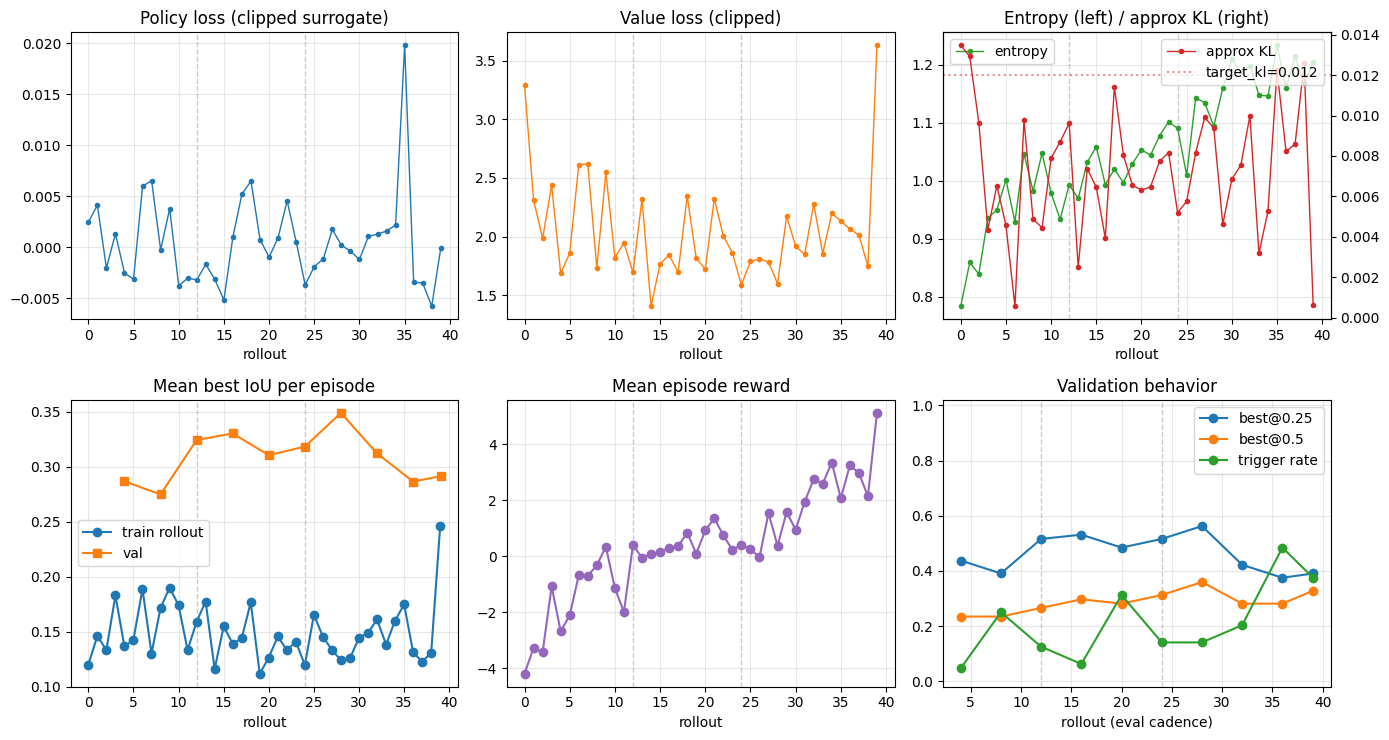

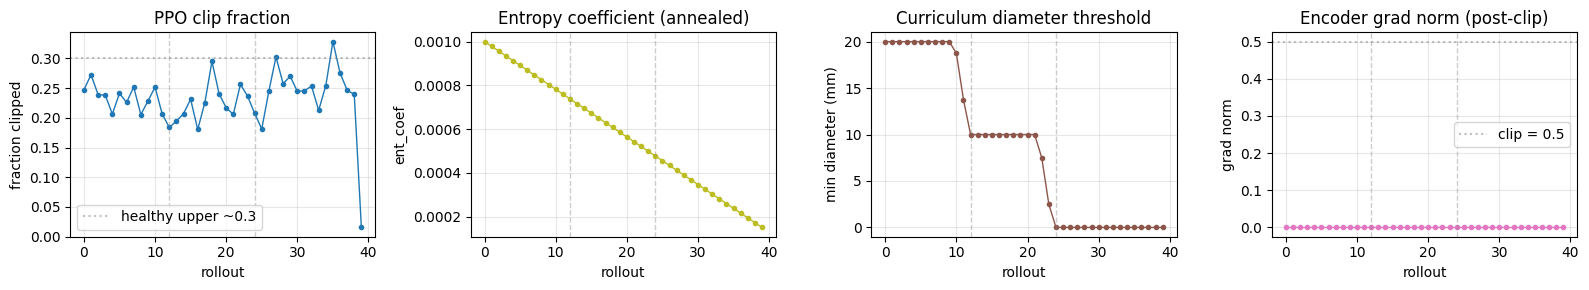

,rollout,global_step,phase,diameter_threshold,policy_loss,value_loss,entropy,trigger_aux_loss,approx_kl,clip_fraction,encoder_grad_norm,entropy_coef,rollout_mean_reward,rollout_mean_best_iou,val_best_iou,val_success_best@0.25,val_success_best@0.5,val_trigger_rate,val_good_trigger_rate,val_bad_trigger_rate
20,21,43008,B_medium,10.000000,-0.000991,1.725024,1.053805,0.387203,0.006313,0.216797,0.0,0.000565,0.919928,0.126524,NaN,NaN,NaN,NaN,NaN,NaN
21,22,45056,B_medium,10.000000,0.000924,2.324019,1.044396,1.147956,0.006472,0.205811,0.0,0.000543,1.349144,0.145729,NaN,NaN,NaN,NaN,NaN,NaN
22,23,47104,B_medium,7.497559,0.004557,2.004614,1.077815,1.482376,0.007738,0.256348,0.0,0.000521,0.745235,0.133346,NaN,NaN,NaN,NaN,NaN,NaN
23,24,49152,B_medium,2.497559,0.000510,1.862470,1.101816,0.009994,0.008165,0.236572,0.0,0.000500,0.219355,0.140836,0.318475,0.515625,0.312500,0.140625,0.062500,0.078125
24,25,51200,C_all,0.000000,-0.003713,1.588375,1.090753,0.388203,0.005196,0.207520,0.0,0.000478,0.404904,0.119774,NaN,NaN,NaN,NaN,NaN,NaN
25,26,53248,C_all,0.000000,-0.001915,1.789285,1.010142,0.683963,0.005757,0.181152,0.0,0.000456,0.248254,0.165417,NaN,NaN,NaN,NaN,NaN,NaN
26,27,55296,C_all,0.000000,-0.001170,1.811665,1.143372,1.077908,0.008162,0.245117,0.0,0.000434,-0.041115,0.145574,NaN,NaN,NaN,NaN,NaN,NaN
27,28,57344,C_all,0.000000,0.001731,1.782947,1.134798,0.840476,0.009905,0.302246,0.0,0.000412,1.539272,0.133451,0.349188,0.562500,0.359375,0.140625,0.046875,0.093750
28,29,59392,C_all,0.000000,0.000194,1.599220,1.094232,0.134441,0.009376,0.257568,0.0,0.000391,0.370328,0.124031,NaN,NaN,NaN,NaN,NaN,NaN
29,30,61440,C_all,0.000000,-0.000398,2.174810,1.159790,1.299653,0.004624,0.269775,0.0,0.000369,1.577240,0.126014,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))

phase_transitions = train_history.get("phase_transitions", [])
n_steps_per = N_STEPS_PER_ROLLOUT
phase_xs = [s / n_steps_per for s, _, _ in phase_transitions if s > 0]

def add_phase_markers(ax):
    for x in phase_xs:
        ax.axvline(x, color="gray", linestyle="--", alpha=0.4, linewidth=1)

axes[0, 0].plot(train_history["policy_loss"], marker=".", linewidth=1)
axes[0, 0].set_title("Policy loss (clipped surrogate)")
axes[0, 0].set_xlabel("rollout"); axes[0, 0].grid(alpha=0.3); add_phase_markers(axes[0, 0])

axes[0, 1].plot(train_history["value_loss"], marker=".", linewidth=1, color="tab:orange")
axes[0, 1].set_title("Value loss (clipped)")
axes[0, 1].set_xlabel("rollout"); axes[0, 1].grid(alpha=0.3); add_phase_markers(axes[0, 1])

axes[0, 2].plot(train_history["entropy"], marker=".", linewidth=1, color="tab:green", label="entropy")
ax2 = axes[0, 2].twinx()
ax2.plot(train_history["approx_kl"], marker=".", linewidth=1, color="tab:red", label="approx KL")
ax2.axhline(TARGET_KL, color="tab:red", linestyle=":", alpha=0.5, label=f"target_kl={TARGET_KL}")
axes[0, 2].set_title("Entropy (left) / approx KL (right)")
axes[0, 2].set_xlabel("rollout"); axes[0, 2].grid(alpha=0.3)
axes[0, 2].legend(loc="upper left"); ax2.legend(loc="upper right")
add_phase_markers(axes[0, 2])

axes[1, 0].plot(train_history["rollout_mean_best_iou"], marker="o", label="train rollout")
if train_history["val_step_at"]:
    val_x = [s / n_steps_per for s in train_history["val_step_at"]]
    axes[1, 0].plot(val_x, train_history["val_best_iou"], marker="s", label="val")
axes[1, 0].set_title("Mean best IoU per episode")
axes[1, 0].set_xlabel("rollout"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)
add_phase_markers(axes[1, 0])

axes[1, 1].plot(train_history["rollout_mean_reward"], marker="o", color="tab:purple")
axes[1, 1].set_title("Mean episode reward")
axes[1, 1].set_xlabel("rollout"); axes[1, 1].grid(alpha=0.3); add_phase_markers(axes[1, 1])

if train_history["val_step_at"]:
    val_x = [s / n_steps_per for s in train_history["val_step_at"]]
    axes[1, 2].plot(val_x, train_history["val_success@0.25"], marker="o", label="best@0.25")
    axes[1, 2].plot(val_x, train_history["val_success@0.5"], marker="o", label="best@0.5")
    axes[1, 2].plot(val_x, train_history["val_trigger_rate"], marker="o", label="trigger rate")
    axes[1, 2].set_ylim(-0.02, 1.02)
axes[1, 2].set_title("Validation behavior")
axes[1, 2].set_xlabel("rollout (eval cadence)"); axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3)
add_phase_markers(axes[1, 2])

plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(1, 4, figsize=(16, 3))

axes2[0].plot(train_history["clipfrac"], marker=".", linewidth=1)
axes2[0].axhline(0.3, color="gray", linestyle=":", alpha=0.5, label="healthy upper ~0.3")
for x in phase_xs:
    axes2[0].axvline(x, color="gray", linestyle="--", alpha=0.4, linewidth=1)
axes2[0].set_title("PPO clip fraction")
axes2[0].set_xlabel("rollout"); axes2[0].set_ylabel("fraction clipped")
axes2[0].legend(); axes2[0].grid(alpha=0.3)

axes2[1].plot(train_history["ent_coef"], marker=".", linewidth=1, color="tab:olive")
for x in phase_xs:
    axes2[1].axvline(x, color="gray", linestyle="--", alpha=0.4, linewidth=1)
axes2[1].set_title("Entropy coefficient (annealed)")
axes2[1].set_xlabel("rollout"); axes2[1].set_ylabel("ent_coef")
axes2[1].grid(alpha=0.3)

axes2[2].plot(train_history["diameter_threshold"], marker=".", linewidth=1, color="tab:brown")
for x in phase_xs:
    axes2[2].axvline(x, color="gray", linestyle="--", alpha=0.4, linewidth=1)
axes2[2].set_title("Curriculum diameter threshold")
axes2[2].set_xlabel("rollout"); axes2[2].set_ylabel("min diameter (mm)")
axes2[2].grid(alpha=0.3)


axes2[3].plot(train_history["encoder_grad_norm"], marker=".", linewidth=1, color="tab:pink")
axes2[3].axhline(ENCODER_MAX_GRAD_NORM, color="gray", linestyle=":", alpha=0.5,
                 label=f"clip = {ENCODER_MAX_GRAD_NORM}")
for x in phase_xs:
    axes2[3].axvline(x, color="gray", linestyle="--", alpha=0.4, linewidth=1)
axes2[3].set_title("Encoder grad norm (post-clip)")
axes2[3].set_xlabel("rollout"); axes2[3].set_ylabel("grad norm")
axes2[3].legend(); axes2[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

def build_training_log_table(history):
    rows = []
    rollout_count = len(history.get("policy_loss", []))
    eval_lookup = {int(step // N_STEPS_PER_ROLLOUT): i for i, step in enumerate(history.get("val_step_at", []))}
    for i in range(rollout_count):
        rollout = i + 1
        row = {
            "rollout": rollout,
            "global_step": rollout * N_STEPS_PER_ROLLOUT,
            "phase": history.get("rollout_phase", [None] * rollout_count)[i],
            "diameter_threshold": history.get("diameter_threshold", [np.nan] * rollout_count)[i],
            "policy_loss": history.get("policy_loss", [np.nan] * rollout_count)[i],
            "value_loss": history.get("value_loss", [np.nan] * rollout_count)[i],
            "entropy": history.get("entropy", [np.nan] * rollout_count)[i],
            "trigger_aux_loss": history.get("trigger_aux_loss", [np.nan] * rollout_count)[i],
            "approx_kl": history.get("approx_kl", [np.nan] * rollout_count)[i],
            "clip_fraction": history.get("clipfrac", [np.nan] * rollout_count)[i],
            "encoder_grad_norm": history.get("encoder_grad_norm", [np.nan] * rollout_count)[i],
            "entropy_coef": history.get("ent_coef", [np.nan] * rollout_count)[i],
            "rollout_mean_reward": history.get("rollout_mean_reward", [np.nan] * rollout_count)[i],
            "rollout_mean_best_iou": history.get("rollout_mean_best_iou", [np.nan] * rollout_count)[i],
        }
        if rollout in eval_lookup:
            j = eval_lookup[rollout]
            row.update({
                "val_best_iou": history.get("val_best_iou", [np.nan])[j],
                "val_success_best@0.25": history.get("val_success@0.25", [np.nan])[j],
                "val_success_best@0.5": history.get("val_success@0.5", [np.nan])[j],
                "val_trigger_rate": history.get("val_trigger_rate", [np.nan])[j],
                "val_good_trigger_rate": history.get("val_successful_trigger_rate", [np.nan])[j],
                "val_bad_trigger_rate": history.get("val_bad_trigger_rate", [np.nan])[j],
            })
        rows.append(row)
    return pd.DataFrame(rows)

training_log_df = build_training_log_table(train_history)
display(training_log_df.tail(20))
training_log_table_path = os.path.join(OUT_DIR, "improvement_2_training_log_table.csv")
training_log_df.to_csv(training_log_table_path, index=False)


## Final Evaluation

Loads the selected checkpoint and reports validation, test, random, and qualitative outputs.


,split,n,mean_final_iou,mean_best_iou,success_final@0.25,success_final@0.5,success_best@0.25,success_best@0.5,trigger_rate,successful_trigger_rate,bad_trigger_rate,mean_trigger_iou,timeout_rate,mean_steps,mean_reversals
0,validation,100,0.157788,0.528293,0.23,0.04,0.78,0.65,0.14,0.03,0.11,0.271817,0.86,36.950001,0.0
1,test,100,0.081612,0.234191,0.12,0.05,0.35,0.16,0.22,0.02,0.20,0.172170,0.78,35.959999,0.0
2,test_random,100,0.032806,0.042341,0.01,0.00,0.03,0.00,1.00,0.00,1.00,0.032806,0.00,6.980000,0.0


,split,mean_raw_final_iou,mean_single_start_final_iou,mean_multistart_gain_iou,multistart_improved_rate,multistart_worse_rate
0,validation,0.109353,0.184271,-0.026483,0.25,0.35
1,test,0.044402,0.057098,0.024514,0.13,0.20


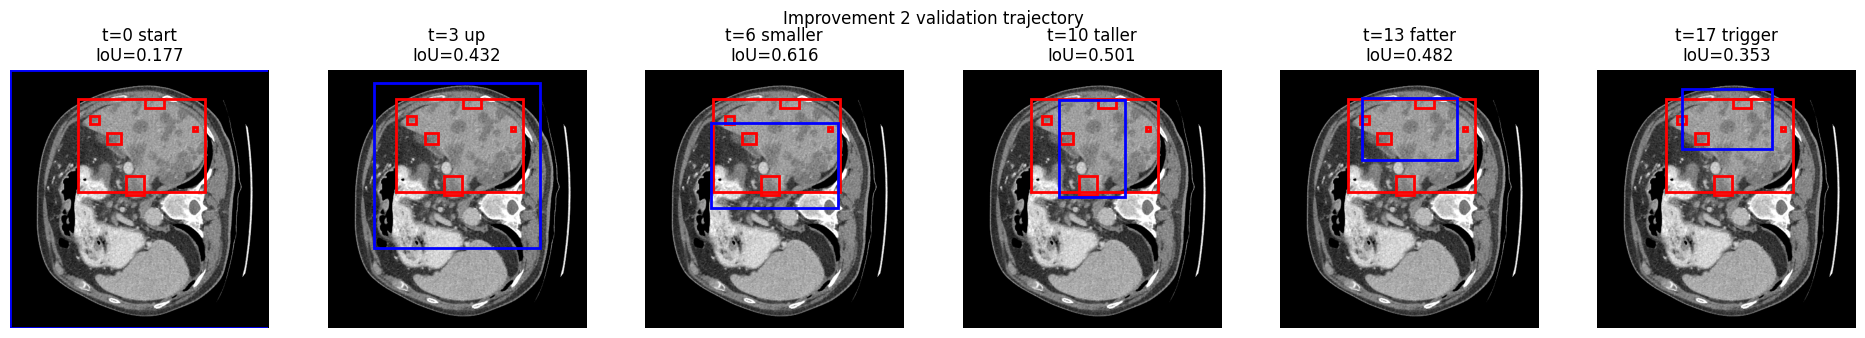

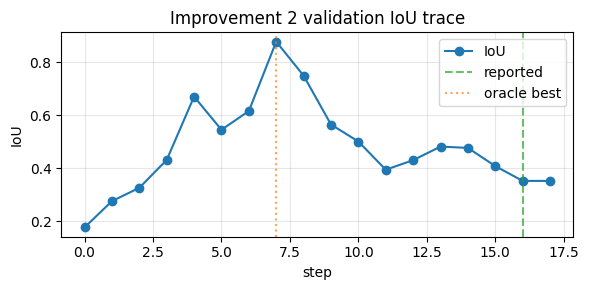

,volume,slice,best_step,best_iou,reported_step,reported_iou,box_area_frac,gt_area_frac,actions
0,108,483,7,0.877758,16,0.352553,0.081024,0.177135,smaller smaller up smaller fatter smaller up t...


In [15]:
best_ckpt_path = os.path.join(OUT_DIR, "improvement_2_best.pt")
best_selection = None
if os.path.exists(best_ckpt_path):
    best_state = torch.load(best_ckpt_path, map_location=DEVICE)
    agent.load_state_dict(best_state["agent"])
    feature_extractor.load_state_dict(best_state["encoder_head"], strict=False)
    best_selection = {
        "step": int(best_state.get("step", -1)),
        "score": float(best_state.get("score", float("nan"))),
        "val_summary": best_state.get("val_summary", None),
    }
    log_line(f"loaded best PPO checkpoint from step {best_selection['step']} score={best_selection['score']:.3f}")
else:
    log_line("WARNING: best PPO checkpoint not found; evaluating final in-memory weights")

val_summary, val_best_example = evaluate_ppo(val_records, render_one=True, multistart=USE_MULTISTART_REPORTING)
test_records = base_test_records[:MAX_VAL_RECORDS] if MAX_VAL_RECORDS else base_test_records
test_summary, test_best_example = evaluate_ppo(test_records, render_one=True, multistart=USE_MULTISTART_REPORTING)
rand_test = evaluate_random(test_records)

REPORT_METRIC_COLUMNS = ['n', 'mean_final_iou', 'mean_best_iou', 'success_final@0.25', 'success_final@0.5', 'success_best@0.25', 'success_best@0.5', 'trigger_rate', 'successful_trigger_rate', 'bad_trigger_rate', 'mean_trigger_iou', 'timeout_rate', 'mean_steps', 'mean_reversals']

def report_metric_row(split, summary):
    row = {"split": split}
    for key in REPORT_METRIC_COLUMNS:
        if key == "mean_reversals":
            row[key] = summary.get("mean_reversals", summary.get("mean_policy_reversals", np.nan))
        else:
            row[key] = summary.get(key, np.nan)
    return row

final_eval_df = pd.DataFrame([
    report_metric_row("validation", val_summary),
    report_metric_row("test", test_summary),
    report_metric_row("test_random", rand_test),
])
display(final_eval_df)
final_eval_table_path = os.path.join(OUT_DIR, "improvement_2_final_eval_table.csv")
final_eval_df.to_csv(final_eval_table_path, index=False)

improvement_diagnostics_df = pd.DataFrame([
    {
        "split": "validation",
        "mean_raw_final_iou": val_summary.get("mean_raw_final_iou", np.nan),
        "mean_single_start_final_iou": val_summary.get("mean_single_start_final_iou", np.nan),
        "mean_multistart_gain_iou": val_summary.get("mean_multistart_gain_iou", np.nan),
        "multistart_improved_rate": val_summary.get("multistart_improved_rate", np.nan),
        "multistart_worse_rate": val_summary.get("multistart_worse_rate", np.nan),
    },
    {
        "split": "test",
        "mean_raw_final_iou": test_summary.get("mean_raw_final_iou", np.nan),
        "mean_single_start_final_iou": test_summary.get("mean_single_start_final_iou", np.nan),
        "mean_multistart_gain_iou": test_summary.get("mean_multistart_gain_iou", np.nan),
        "multistart_improved_rate": test_summary.get("multistart_improved_rate", np.nan),
        "multistart_worse_rate": test_summary.get("multistart_worse_rate", np.nan),
    },
])
display(improvement_diagnostics_df)

metrics = {
    "val_improvement_2": val_summary,
    "test_improvement_2": test_summary,
    "test_random": rand_test,
    "best_improvement_2_selection": best_selection,
    "report_protocol_name": REPORT_PROTOCOL_NAME,
    "report_best_on_timeout": REPORT_BEST_ON_TIMEOUT,
    "report_best_on_trigger": REPORT_BEST_ON_TRIGGER,
    "report_timeout_box_selection": REPORT_TIMEOUT_BOX_SELECTION,
    "use_multistart_reporting": USE_MULTISTART_REPORTING,
    "multistart_eval_during_training": MULTISTART_EVAL_DURING_TRAINING,
    "multistart_num_starts": MULTISTART_NUM_STARTS,
    "multistart_min_report_step": MULTISTART_MIN_REPORT_STEP,
    "multistart_max_report_area_frac": MULTISTART_MAX_REPORT_AREA_FRAC,
    "oracle_val_sample": oracle_summary(val_records, n=min(64, len(val_records)),
                                        trigger_iou=TRIGGER_EVAL_IOU, start_box_mode="full"),
    "post_bc_val": bc_pre,
}
metrics_path = os.path.join(OUT_DIR, "improvement_2_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
log_line(f"saved metrics -> {metrics_path}")

if val_best_example is not None:
    best_frame = best_frame_from_rollout(val_best_example[1])
    report_frame = next((f for f in val_best_example[1] if f.get("selected_multistart_report")),
                        best_confidence_frame_from_rollout(val_best_example[1]))
    visualize_rollout(val_best_example[0], val_best_example[1], "Improvement 2 validation trajectory")
    plt.figure(figsize=(6, 3))
    plt.plot([f["iou"] for f in val_best_example[1]], marker="o", label="IoU")
    plt.axvline(report_frame["step"], color="tab:green", linestyle="--", alpha=0.7, label="reported")
    plt.axvline(best_frame["step"], color="tab:orange", linestyle=":", alpha=0.7, label="oracle best")
    plt.title("Improvement 2 validation IoU trace")
    plt.xlabel("step"); plt.ylabel("IoU"); plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.show()

    qualitative_rollout_df = pd.DataFrame([{
        "volume": int(val_best_example[0].record["vid"]),
        "slice": int(val_best_example[0].record["slice"]),
        "best_step": int(best_frame["step"]),
        "best_iou": float(best_frame["iou"]),
        "reported_step": int(report_frame["step"]),
        "reported_iou": float(report_frame["iou"]),
        "box_area_frac": box_area_frac(report_frame["box"], val_best_example[0].image.shape),
        "gt_area_frac": max_gt_area_frac(val_best_example[0]),
        "actions": " ".join(ACTION_NAMES[f["action"]] for f in val_best_example[1] if f["action"] is not None),
    }])
    display(qualitative_rollout_df)

    log_line(
        f"Displayed validation scan: vol={val_best_example[0].record['vid']} "
        f"slice={val_best_example[0].record['slice']} best_step={best_frame['step']} "
        f"best_IoU={best_frame['iou']:.3f} report_step={report_frame['step']} "
        f"reported_IoU={report_frame['iou']:.3f} "
        f"box_area={box_area_frac(report_frame['box'], val_best_example[0].image.shape):.3f} "
        f"gt_area={max_gt_area_frac(val_best_example[0]):.3f}"
    )
    log_line("Actions:", [ACTION_NAMES[f["action"]] for f in val_best_example[1] if f["action"] is not None])


## Acceptance Criteria

Records the report-readiness checks used for the run.


## Acceptance Criteria

Records the report-readiness checks used for the run.
